# Flexynesis Workshop

모델/데이터 상세 설명 → [Workshop Site](https://cykim-saihst.github.io/flexynesis-workshop/)


In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import flexynesis
import torch
import numpy as np
import pandas as pd
import time
from collections import Counter

torch.set_num_threads(4)

print("flexynesis:", flexynesis.__version__)
print("CUDA available:", torch.cuda.is_available())


flexynesis: 1.1.7
CUDA available: True


## Section 0. 데이터 로드


In [2]:
USE_MINI  = True   # 빠른 테스트: True / 실제 분석: False
HPO_ITER  = 3      # HPO 반복 횟수 (실제 분석: 50+)

DATA_DIR = "/data01/storage/flexynesis_workshop/brca_metabric_processed"
MINI_DIR  = "/data01/storage/flexynesis_workshop/brca_mini"

PATH = MINI_DIR if USE_MINI else DATA_DIR
print(f"사용 데이터: {PATH} ({'mini' if USE_MINI else 'full'})")


사용 데이터: /data01/storage/flexynesis_workshop/brca_mini (mini)


In [3]:
import shutil

def make_mini_dataset(src_dir, dst_dir, n_train=200, n_test=80, seed=42,
                       stratify_col='CLAUDIN_SUBTYPE', min_per_class=2):
    """풀 데이터에서 stratified 서브셋 생성 (클래스별 최소 min_per_class 보장)"""
    if os.path.exists(dst_dir):
        print(f"미니 데이터 이미 존재: {dst_dir}")
        return

    np.random.seed(seed)

    for split, n in [('train', n_train), ('test', n_test)]:
        src = os.path.join(src_dir, split)
        dst = os.path.join(dst_dir, split)
        os.makedirs(dst, exist_ok=True)

        clin = pd.read_csv(os.path.join(src, 'clin.csv'), index_col=0)

        # Stratified sampling: 각 클래스에서 비율대로 뽑되 min_per_class 보장
        if stratify_col and stratify_col in clin.columns:
            groups = clin.groupby(stratify_col)
            chosen_list = []
            # 1단계: 각 클래스에서 최소 min_per_class 확보
            for cls, grp in groups:
                take = max(min_per_class, int(round(len(grp) / len(clin) * n)))
                take = min(take, len(grp))
                chosen_list.append(grp.sample(take, random_state=seed))
            chosen_df = pd.concat(chosen_list)
            # 2단계: n보다 많으면 랜덤으로 줄임
            if len(chosen_df) > n:
                chosen_df = chosen_df.sample(n, random_state=seed)
            chosen = chosen_df.index
            print(f"[{split}] stratified {len(chosen)} samples")
            print('  클래스별:', chosen_df[stratify_col].value_counts().to_dict())
        else:
            chosen = clin.sample(min(n, len(clin)), random_state=seed).index

        clin.loc[chosen].to_csv(os.path.join(dst, 'clin.csv'))

        for fname in os.listdir(src):
            if fname == 'clin.csv':
                continue
            fpath = os.path.join(src, fname)
            df = pd.read_csv(fpath, index_col=0)
            valid = [s for s in chosen if s in df.columns]
            df[valid].to_csv(os.path.join(dst, fname))
            print(f"  {split}/{fname}: {df.shape[0]} features × {len(valid)} samples")

    # STRING DB 파일 복사 (GNN용)
    for f in os.listdir(src_dir):
        if f.endswith('.gz'):
            shutil.copy(os.path.join(src_dir, f), dst_dir)

    print(f"\n미니 데이터 생성 완료: {dst_dir}")

make_mini_dataset(DATA_DIR, MINI_DIR)

[train] stratified 200 samples
  클래스별: {'LumA': 71, 'LumB': 50, 'Her2': 23, 'Basal': 22, 'claudin-low': 18, 'Normal': 14, 'NC': 2}
  train/cna.csv: 22542 features × 200 samples
  train/mut.csv: 173 features × 200 samples
  train/gex.csv: 20603 features × 200 samples
[test] stratified 80 samples
  클래스별: {'LumA': 29, 'LumB': 18, 'Her2': 9, 'claudin-low': 9, 'Basal': 8, 'Normal': 6, 'NC': 1}
  test/cna.csv: 22542 features × 80 samples
  test/mut.csv: 173 features × 80 samples
  test/gex.csv: 20603 features × 80 samples

미니 데이터 생성 완료: /data01/storage/flexynesis_workshop/brca_mini


> 파라미터 상세 설명 → [DataImporter Reference](https://cykim-saihst.github.io/flexynesis-workshop/data_guide.html)


In [4]:
data_importer = flexynesis.data.DataImporter(
    path=PATH,
    data_types=['gex', 'cna'],        # 사용할 omics 레이어
    concatenate=False,                 # False=레이어별 개별 encoder

    # --- Feature selection ---
    top_percentile=10,                 # Laplacian score 상위 N%
    min_features=50,                   # 최소 보장 feature 수
    correlation_threshold=0.9,
    variance_threshold=0.8,

    # --- 기타 ---
    na_threshold=0.1,
    log_transform=False,
    covariates=None,
    downsample=0,
    restrict_to_features=None,
)
train_dataset, test_dataset = data_importer.import_data()


[INFO] ================= Importing Data =================
[INFO] Validating data folders...

[INFO] ----------------- Reading Data ----------------- 
[INFO] Importing /data01/storage/flexynesis_workshop/brca_mini/train/clin.csv...
[INFO] Importing /data01/storage/flexynesis_workshop/brca_mini/train/cna.csv...
[INFO] Importing /data01/storage/flexynesis_workshop/brca_mini/train/gex.csv...

[INFO] ----------------- Reading Data ----------------- 
[INFO] Importing /data01/storage/flexynesis_workshop/brca_mini/test/clin.csv...
[INFO] Importing /data01/storage/flexynesis_workshop/brca_mini/test/cna.csv...
[INFO] Importing /data01/storage/flexynesis_workshop/brca_mini/test/gex.csv...

[INFO] ----------------- Checking for problems with the input data ----------------- 
[INFO] Data structure is valid with no errors or warnings.

[INFO] ----------------- Processing Data (train) ----------------- 

[INFO] ----------------- Cleaning Up Data ----------------- 

[INFO] working on layer:  gex
[INF

Filtering redundant features: 100%|██████████| 412/412 [00:00<00:00, 9757.33it/s]


[INFO] Implementing feature selection using laplacian score for layer: cna with  4510 features  and  199  samples 


Filtering redundant features: 100%|██████████| 451/451 [00:00<00:00, 506054.33it/s]



[INFO] ----------------- Processing Data (test) ----------------- 

[INFO] ----------------- Cleaning Up Data ----------------- 

[INFO] working on layer:  gex
[INFO] Number of NA values:  0
[INFO] DataFrame gex - Removed 16482 features.

[INFO] working on layer:  cna
[INFO] Number of NA values:  0
[INFO] DataFrame cna - Removed 18033 features.
[INFO] DataFrame gex - Removed 0 samples (0.00%).
[INFO] DataFrame cna - Removed 0 samples (0.00%).

[INFO] ----------------- Harmonizing Data Sets ----------------- 

[INFO] ----------------- Finished Harmonizing ----------------- 

[INFO] ----------------- Normalizing Data ----------------- 

[INFO] ----------------- Normalizing Data ----------------- 
[INFO] Training Data Stats:  {'feature_count in: cna': 451, 'feature_count in: gex': 371, 'sample_count': 199}
[INFO] Test Data Stats:  {'feature_count in: cna': 451, 'feature_count in: gex': 371, 'sample_count': 80}
[INFO] Merging Feature Logs...
[INFO] Data import successful.


In [5]:
print("Train:", len(train_dataset.samples), "samples")
print("Test: ", len(test_dataset.samples),  "samples")
print("Features:", {k: v.shape[1] for k, v in train_dataset.dat.items()})

lmap = train_dataset.label_mappings['CLAUDIN_SUBTYPE']
counts = Counter(train_dataset.ann['CLAUDIN_SUBTYPE'].numpy())
print("CLAUDIN_SUBTYPE:", {lmap[k]: v for k, v in counts.items()})

Train: 199 samples
Test:  80 samples
Features: {'cna': 451, 'gex': 371}
CLAUDIN_SUBTYPE: {'Her2': 23, 'LumA': 71, 'LumB': 50, 'Normal': 14, 'Basal': 22, 'claudin-low': 17, 'NC': 2}


In [6]:
all_metrics  = []
training_log = []

## Section 1. DirectPred — 분류


> 파라미터 상세 설명 → [HyperparameterTuning Reference](https://cykim-saihst.github.io/flexynesis-workshop/hpo_guide.html)


Seed set to 42
Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 105, 'hidden_dim_factor': 0.25503043695984917, 'lr': 0.00362561763457623, 'supervisor_hidden_dim': 22, 'epochs': 500, 'batch_size': 32}


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │  109 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │ 22.2 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  2.5 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 134 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 134 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: UserWarning:
Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 32. To avoid any 
miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: UserWarning:
Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 7. To avoid any 
miscalculations, use `self.log(..., batch_size=batch_size)`.

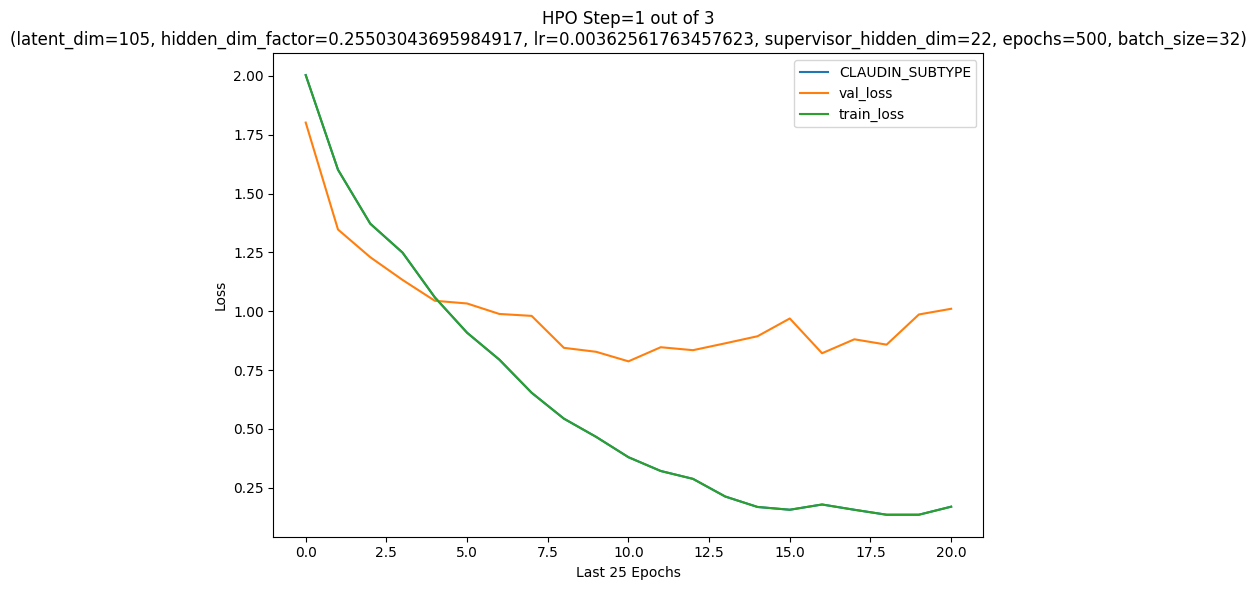

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.0104180574417114     │
│         val_loss          │    1.0104180574417114     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [00:09<00:18,  9.02s/it, Iteration=1, Best Loss=1.01]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 1.0104180574417114; best params: {'latent_dim': 105, 'hidden_dim_factor': 0.25503043695984917, 'lr': 0.00362561763457623, 'supervisor_hidden_dim': 22, 'epochs': 500, 'batch_size': 32} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 67, 'hidden_dim_factor': 0.3001125833417066, 'lr': 0.0001930783753654713, 'supervisor_hidden_dim': 24, 'epochs': 500, 'batch_size': 128}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │  119 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │  9.0 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  1.9 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 130 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 130 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: UserWarning:
Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 39. To avoid any 
miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: UserWarning:
Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 128. To avoid any 
miscalculations, use `self.log(..., batch_size=batch_size)`.

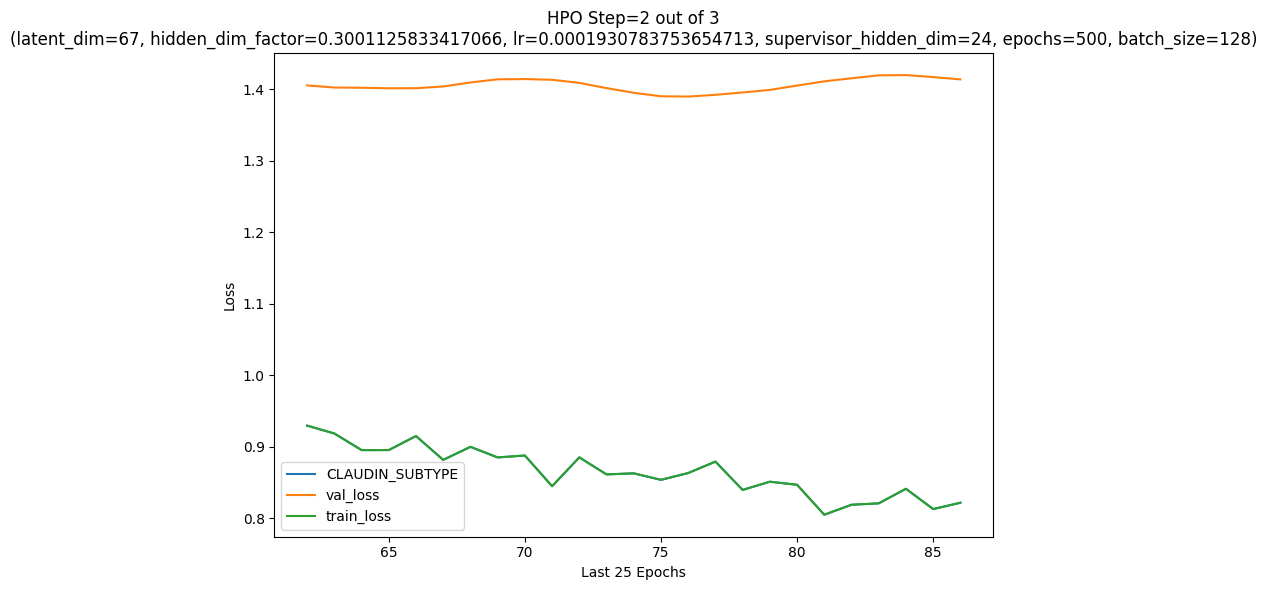

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.4136062860488892     │
│         val_loss          │    1.4136062860488892     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [00:34<00:18, 18.69s/it, Iteration=2, Best Loss=1.01]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 1.0104180574417114; best params: {'latent_dim': 105, 'hidden_dim_factor': 0.25503043695984917, 'lr': 0.00362561763457623, 'supervisor_hidden_dim': 22, 'epochs': 500, 'batch_size': 32} since 1 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 121, 'hidden_dim_factor': 0.2002336297523043, 'lr': 0.009647685075720105, 'supervisor_hidden_dim': 23, 'epochs': 500, 'batch_size': 32}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │ 88.6 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │ 29.4 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  3.0 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 121 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 121 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

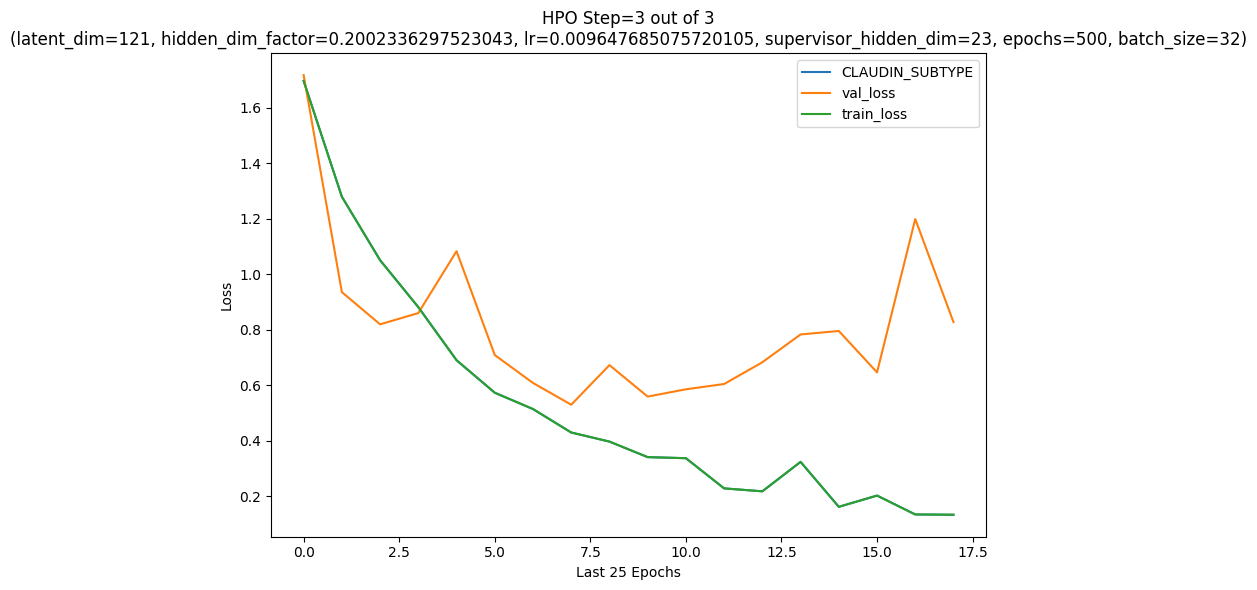

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.8270796537399292     │
│         val_loss          │    0.8270796537399292     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [00:42<00:00, 14.21s/it, Iteration=3, Best Loss=0.827]

[INFO] current best val loss: 0.8270796537399292; best params: {'latent_dim': 121, 'hidden_dim_factor': 0.2002336297523043, 'lr': 0.009647685075720105, 'supervisor_hidden_dim': 23, 'epochs': 500, 'batch_size': 32} since 0 hpo iterations
소요 시간: 0.7분
저장: ./models/DirectPred_clf.pth


In [7]:
tuner = flexynesis.main.HyperparameterTuning(
    dataset=train_dataset,
    model_class=flexynesis.models.DirectPred,
    target_variables=['CLAUDIN_SUBTYPE'],
    config_name='DirectPred',
    n_iter=HPO_ITER,
    val_size=0.2, use_cv=False, cv_splits=5,
    use_loss_weighting=True, early_stop_patience=10, plot_losses=True,
    surv_event_var=None, surv_time_var=None,
    batch_variables=None, device_type=None,
)
_t0 = time.time()
model_dp, params_dp = tuner.perform_tuning()
_elapsed = time.time() - _t0
training_log.append({'model': 'DirectPred (clf)', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f"소요 시간: {_elapsed/60:.1f}분")
os.makedirs('./models', exist_ok=True)
torch.save(model_dp, './models/DirectPred_clf.pth')
print("저장: ./models/DirectPred_clf.pth")

In [8]:
metrics_dp = flexynesis.utils.evaluate_wrapper(
    method='DirectPred',
    y_pred_dict=model_dp.predict(test_dataset),
    dataset=test_dataset,
)
all_metrics.append(metrics_dp)
metrics_dp

,method,var,variable_type,metric,value
0,DirectPred,CLAUDIN_SUBTYPE,categorical,balanced_acc,0.612479
1,DirectPred,CLAUDIN_SUBTYPE,categorical,f1_score,0.711945
2,DirectPred,CLAUDIN_SUBTYPE,categorical,kappa,0.637224
3,DirectPred,CLAUDIN_SUBTYPE,categorical,average_auroc,0.931027
4,DirectPred,CLAUDIN_SUBTYPE,categorical,average_aupr,0.790874


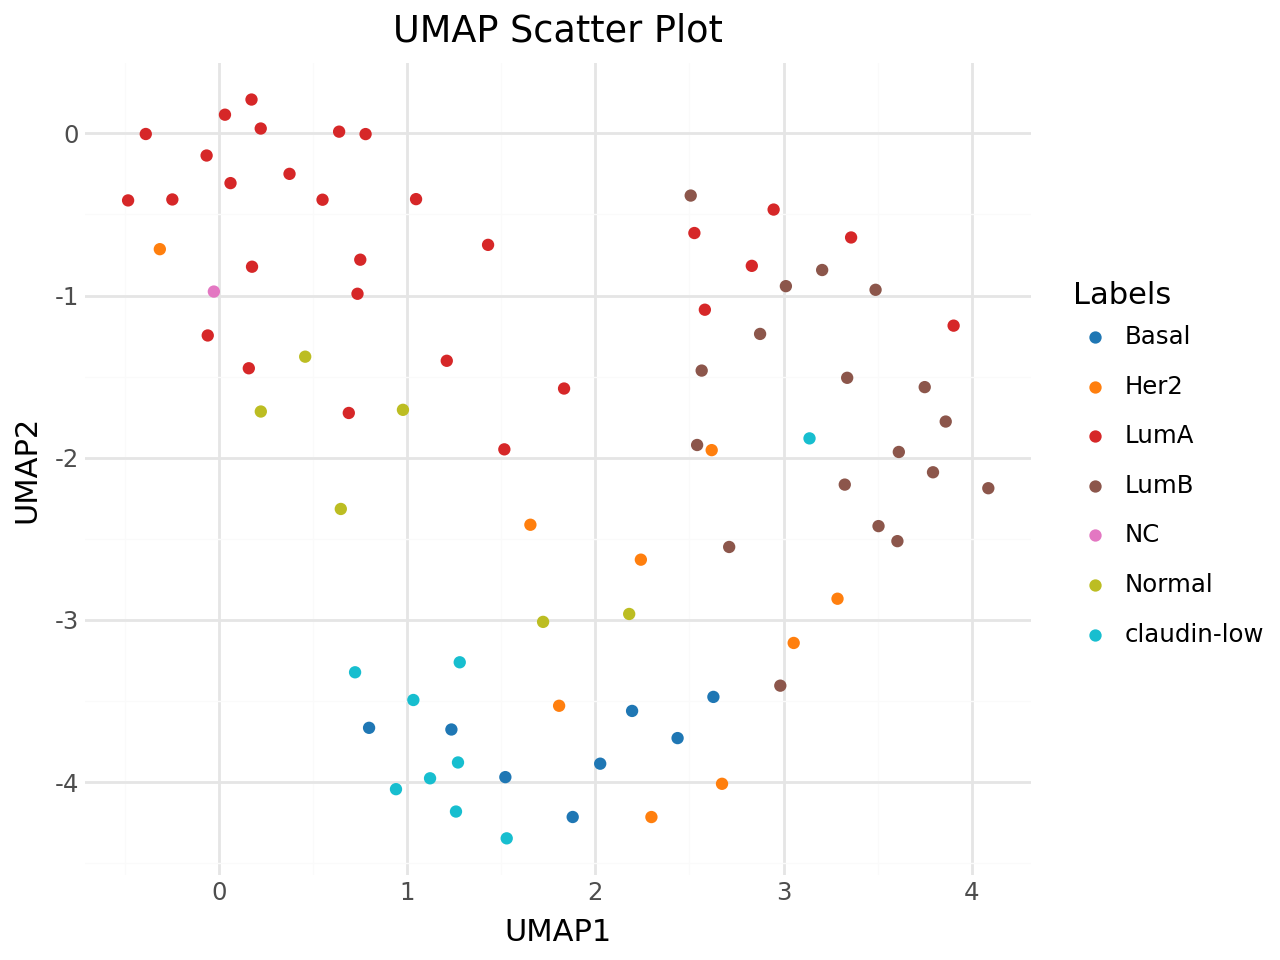

In [9]:
E_dp = model_dp.transform(test_dataset)
labels = [test_dataset.label_mappings['CLAUDIN_SUBTYPE'][x]
          for x in test_dataset.ann['CLAUDIN_SUBTYPE'].numpy()]
flexynesis.utils.plot_dim_reduced(E_dp, labels, method='umap', color_type='categorical')

## Section 2. DirectPred — 생존분석


> 파라미터 상세 설명 → [HyperparameterTuning Reference](https://cykim-saihst.github.io/flexynesis-workshop/hpo_guide.html)


Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 100, 'hidden_dim_factor': 0.31789683469365776, 'lr': 0.0045533228152233925, 'supervisor_hidden_dim': 22, 'epochs': 500, 'batch_size': 32}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │  134 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │ 20.1 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  2.3 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 157 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 157 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

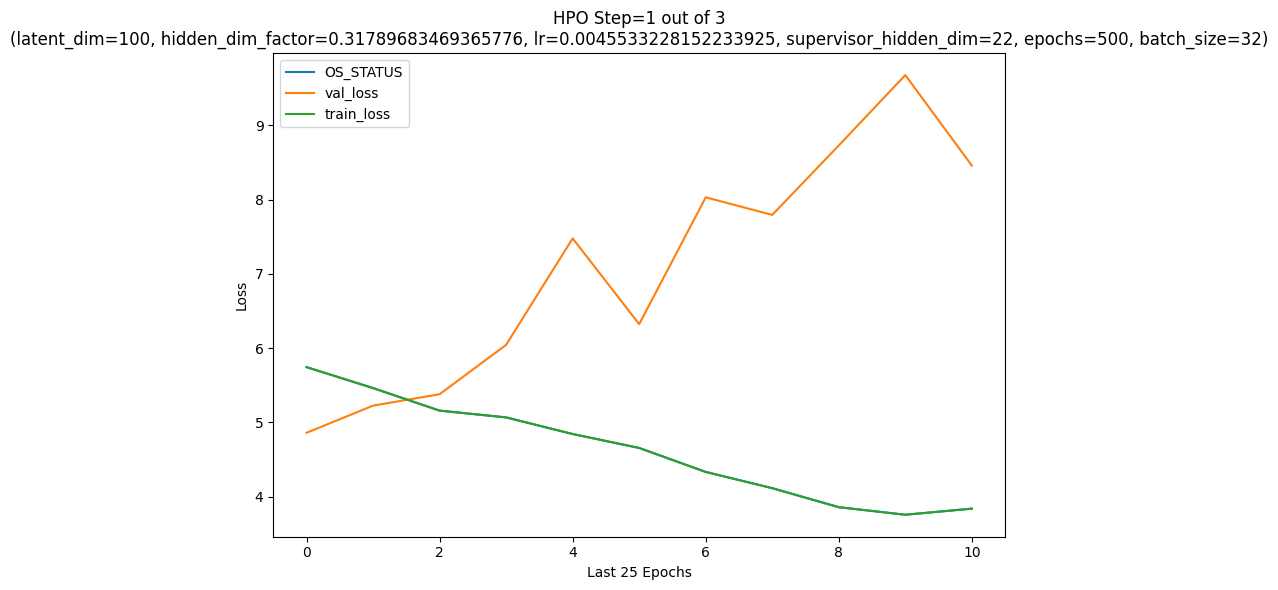

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         OS_STATUS         │     8.458761215209961     │
│         val_loss          │     8.458761215209961     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [00:04<00:09,  4.70s/it, Iteration=1, Best Loss=8.46]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 8.458761215209961; best params: {'latent_dim': 100, 'hidden_dim_factor': 0.31789683469365776, 'lr': 0.0045533228152233925, 'supervisor_hidden_dim': 22, 'epochs': 500, 'batch_size': 32} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 18, 'hidden_dim_factor': 0.2226077181057387, 'lr': 0.002417846882276413, 'supervisor_hidden_dim': 21, 'epochs': 500, 'batch_size': 64}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │ 79.4 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │    666 │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │    485 │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 80.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 80.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: UserWarning:
Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 64. To avoid any 
miscalculations, use `self.log(..., batch_size=batch_size)`.

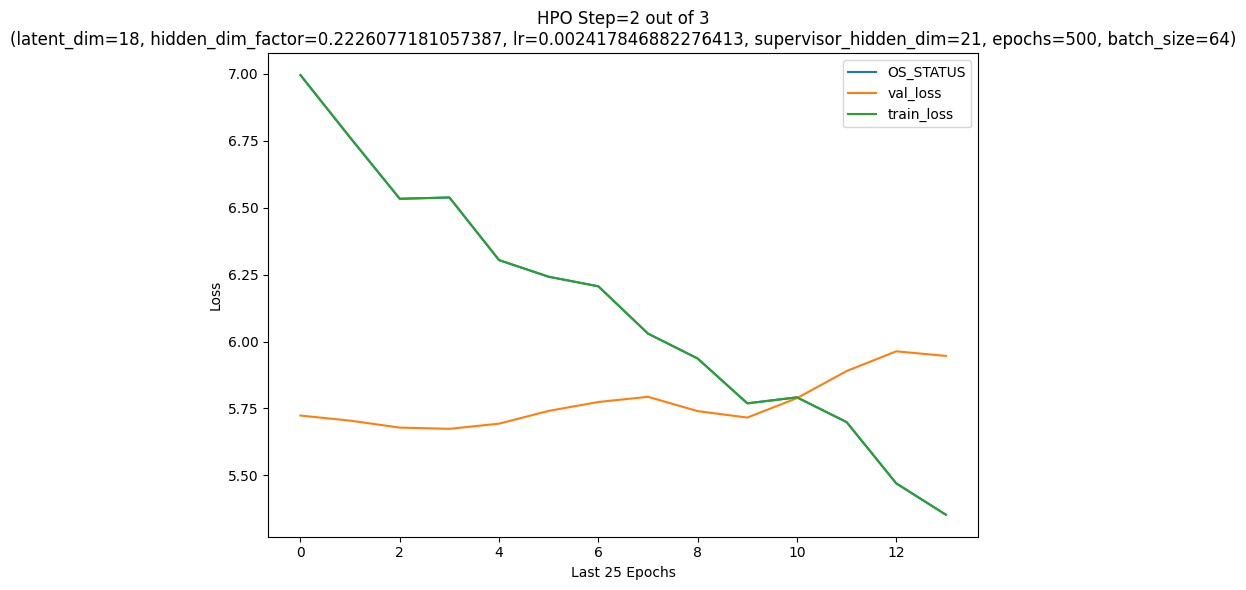

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         OS_STATUS         │     5.946399211883545     │
│         val_loss          │     5.946399211883545     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [00:08<00:04,  4.42s/it, Iteration=2, Best Loss=5.95]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 5.946399211883545; best params: {'latent_dim': 18, 'hidden_dim_factor': 0.2226077181057387, 'lr': 0.002417846882276413, 'supervisor_hidden_dim': 21, 'epochs': 500, 'batch_size': 64} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 97, 'hidden_dim_factor': 0.42712436061273684, 'lr': 0.0005697719939974019, 'supervisor_hidden_dim': 14, 'epochs': 500, 'batch_size': 32}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │  180 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │ 18.9 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  1.4 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 200 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 200 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

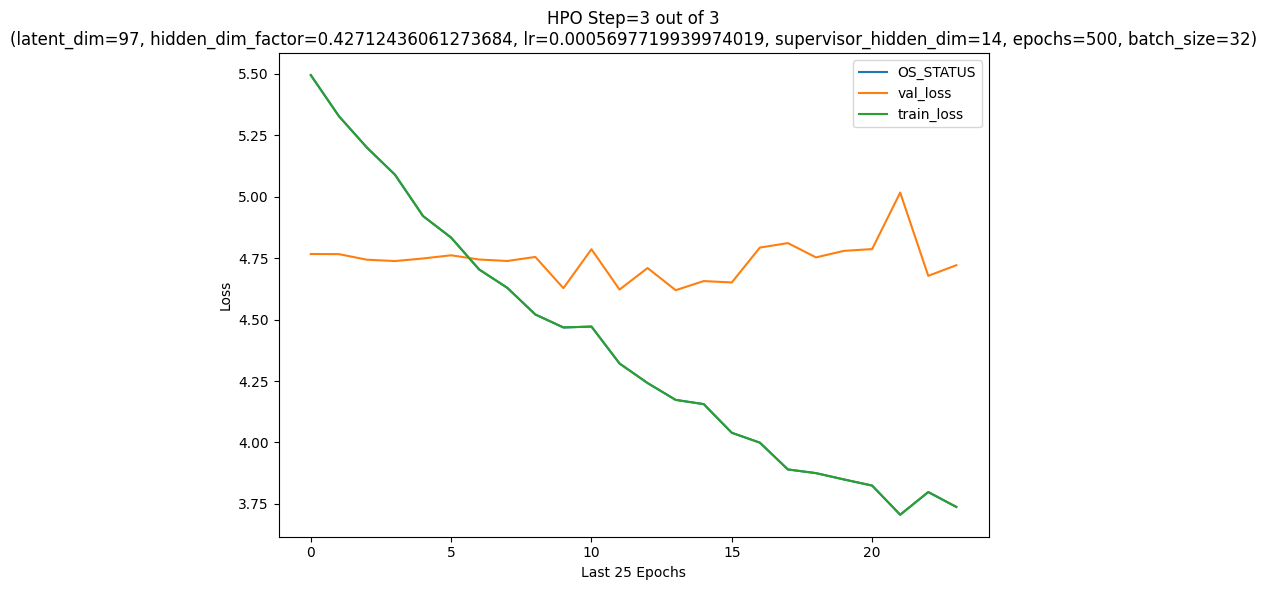

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         OS_STATUS         │     4.721218585968018     │
│         val_loss          │     4.721218585968018     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [00:19<00:00,  6.49s/it, Iteration=3, Best Loss=4.72]

[INFO] current best val loss: 4.721218585968018; best params: {'latent_dim': 97, 'hidden_dim_factor': 0.42712436061273684, 'lr': 0.0005697719939974019, 'supervisor_hidden_dim': 14, 'epochs': 500, 'batch_size': 32} since 0 hpo iterations
소요 시간: 0.3분
저장: ./models/DirectPred_surv.pth


In [10]:
tuner = flexynesis.main.HyperparameterTuning(
    dataset=train_dataset,
    model_class=flexynesis.models.DirectPred,
    target_variables=[],
    config_name='DirectPred',
    n_iter=HPO_ITER,
    val_size=0.2, use_cv=False, cv_splits=5,
    use_loss_weighting=True, early_stop_patience=10, plot_losses=True,
    surv_event_var='OS_STATUS', surv_time_var='OS_MONTHS',
    batch_variables=None, device_type=None,
)
_t0 = time.time()
model_surv, params_surv = tuner.perform_tuning()
_elapsed = time.time() - _t0
training_log.append({'model': 'DirectPred (surv)', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f"소요 시간: {_elapsed/60:.1f}분")
torch.save(model_surv, './models/DirectPred_surv.pth')
print("저장: ./models/DirectPred_surv.pth")

In [11]:
metrics_surv = flexynesis.utils.evaluate_wrapper(
    method='DirectPred_survival',
    y_pred_dict=model_surv.predict(test_dataset),
    dataset=test_dataset,
    surv_event_var=model_surv.surv_event_var,
    surv_time_var=model_surv.surv_time_var,
)
all_metrics.append(metrics_surv)
metrics_surv

,method,var,variable_type,metric,value
0,DirectPred_survival,OS_STATUS,categorical,balanced_acc,0.468750
1,DirectPred_survival,OS_STATUS,categorical,f1_score,0.432000
2,DirectPred_survival,OS_STATUS,categorical,kappa,-0.073620
3,DirectPred_survival,OS_STATUS,categorical,average_auroc,0.389974
4,DirectPred_survival,OS_STATUS,categorical,average_aupr,0.553138


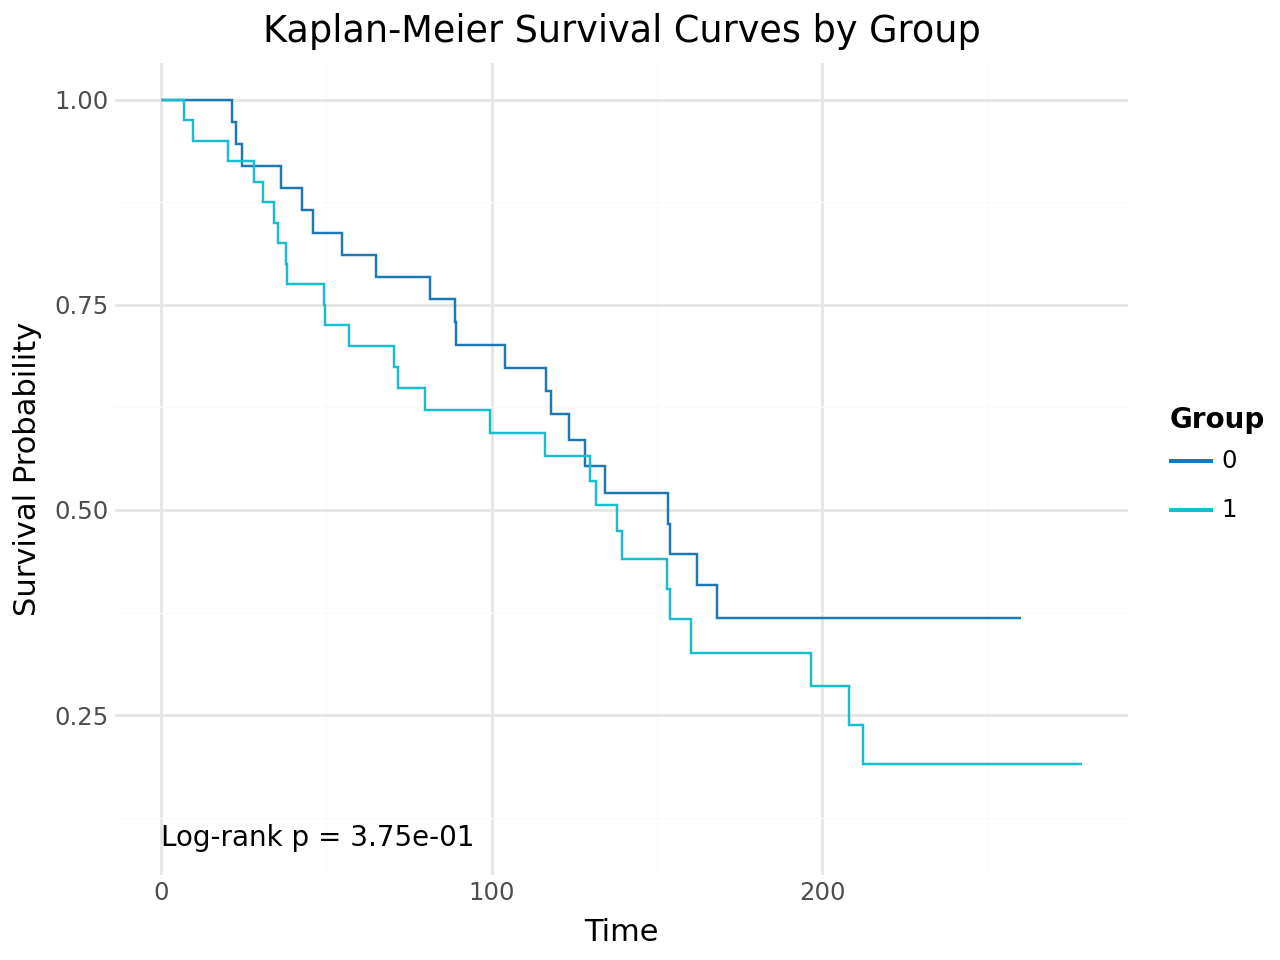

In [12]:
outputs = model_surv.predict(test_dataset)['OS_STATUS']
if outputs.ndim > 1:
    outputs = outputs[:, 0]
risk_scores = np.exp(outputs.flatten())
groups = np.digitize(risk_scores, np.quantile(risk_scores, [0.5]))

durations = test_dataset.ann['OS_MONTHS'].float()
events    = test_dataset.ann['OS_STATUS'].float()
valid_t   = ~torch.isnan(durations) & ~torch.isnan(events)
valid_np  = valid_t.numpy()

flexynesis.utils.plot_kaplan_meier_curves(
    durations[valid_t], events[valid_t], groups[valid_np]
)

## Section 3. supervised_vae — 분류


> 파라미터 상세 설명 → [HyperparameterTuning Reference](https://cykim-saihst.github.io/flexynesis-workshop/hpo_guide.html)


Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 42, 'hidden_dim_factor': 0.4015102053217571, 'supervisor_hidden_dim': 23, 'lr': 0.0005203857985647049, 'epochs': 500, 'batch_size': 128}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │  165 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │  3.6 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │  3.6 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │  152 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │  1.2 K │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 325 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 325 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 38                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

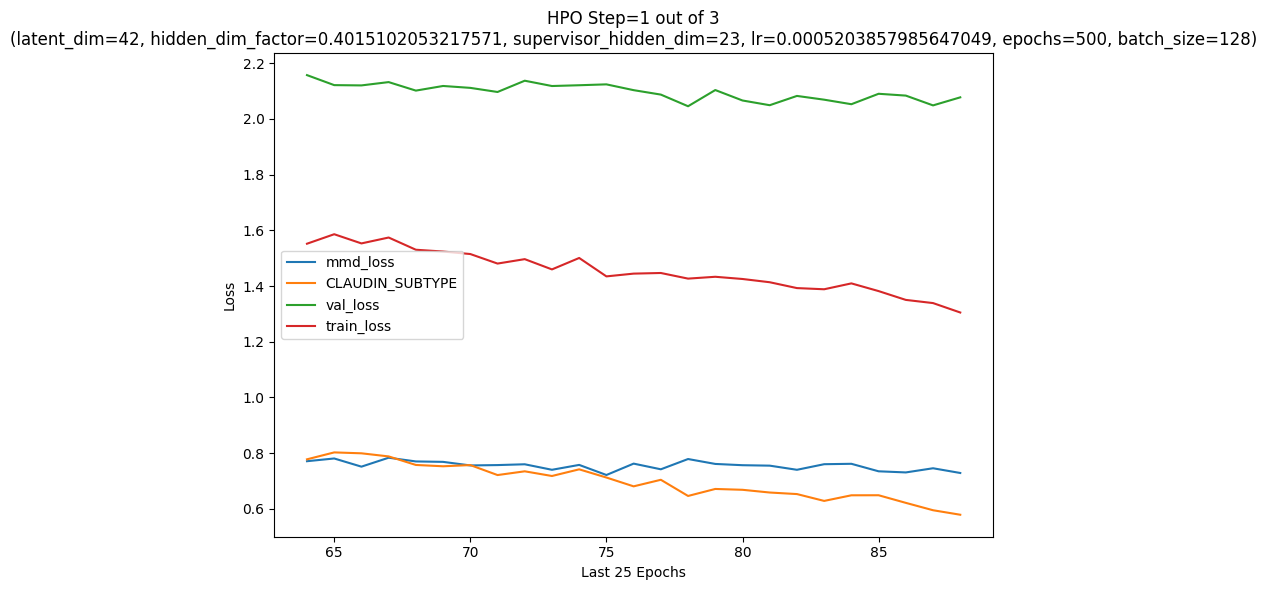

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.2306619882583618     │
│         mmd_loss          │     0.798128604888916     │
│         val_loss          │    2.0287904739379883     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [00:19<00:38, 19.07s/it, Iteration=1, Best Loss=2.03]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 2.0287904739379883; best params: {'latent_dim': 42, 'hidden_dim_factor': 0.4015102053217571, 'supervisor_hidden_dim': 23, 'lr': 0.0005203857985647049, 'epochs': 500, 'batch_size': 128} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 74, 'hidden_dim_factor': 0.43169551752069185, 'supervisor_hidden_dim': 20, 'lr': 0.005062476271565483, 'epochs': 500, 'batch_size': 64}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │  200 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │ 11.0 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │ 11.0 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │  174 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │  1.7 K │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 399 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 399 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 38                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

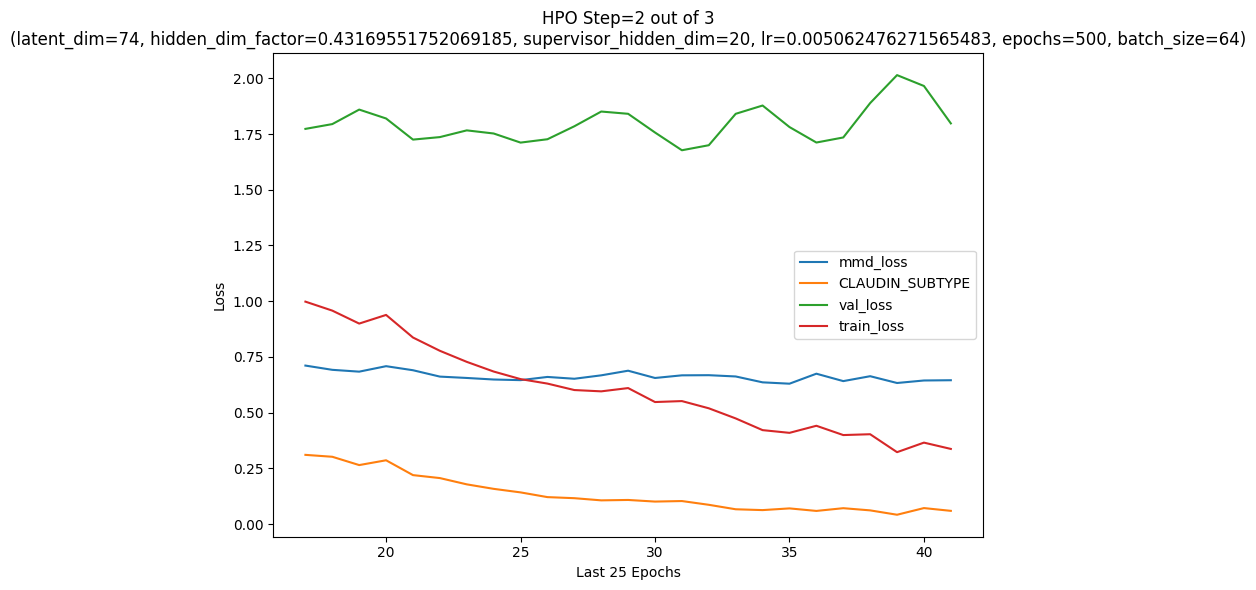

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │     1.165968894958496     │
│         mmd_loss          │    0.6262515783309937     │
│         val_loss          │    1.7922204732894897     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [00:34<00:16, 16.79s/it, Iteration=2, Best Loss=1.79]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 1.7922204732894897; best params: {'latent_dim': 74, 'hidden_dim_factor': 0.43169551752069185, 'supervisor_hidden_dim': 20, 'lr': 0.005062476271565483, 'epochs': 500, 'batch_size': 64} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 114, 'hidden_dim_factor': 0.32104485986371917, 'supervisor_hidden_dim': 11, 'lr': 0.00011417350999721898, 'epochs': 500, 'batch_size': 64}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │  170 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │ 26.1 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │ 26.1 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │  140 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │  1.4 K │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 364 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 364 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 38                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

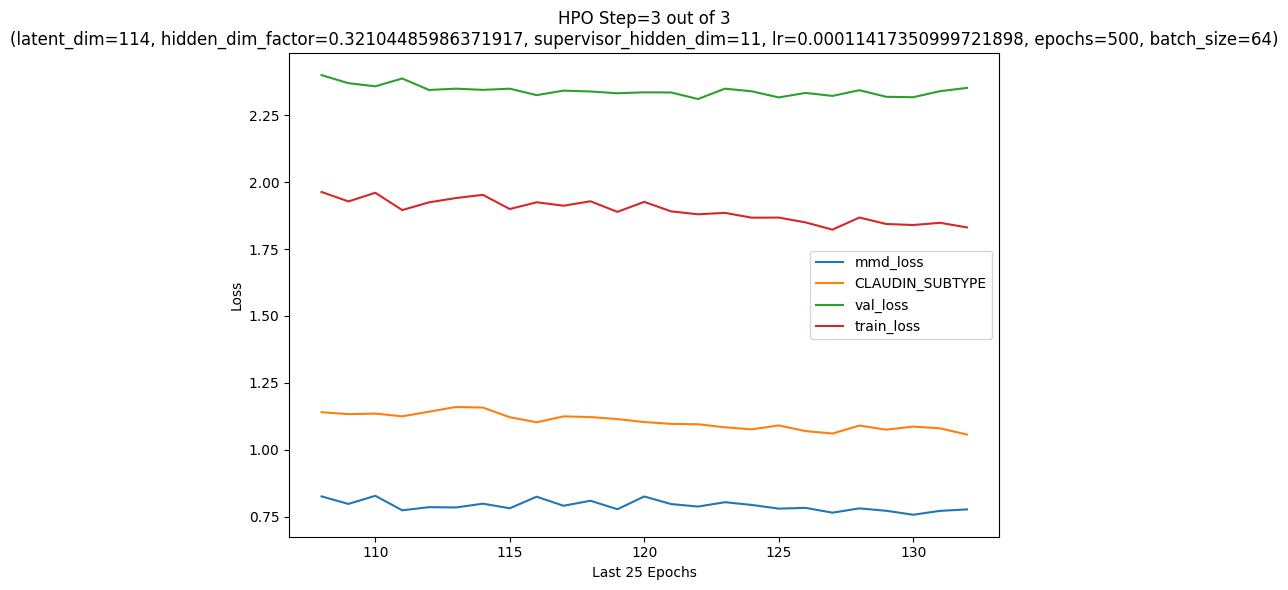

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.4166409969329834     │
│         mmd_loss          │     0.878006637096405     │
│         val_loss          │     2.294647693634033     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [01:20<00:00, 26.88s/it, Iteration=3, Best Loss=1.79]

[INFO] current best val loss: 1.7922204732894897; best params: {'latent_dim': 74, 'hidden_dim_factor': 0.43169551752069185, 'supervisor_hidden_dim': 20, 'lr': 0.005062476271565483, 'epochs': 500, 'batch_size': 64} since 1 hpo iterations
소요 시간: 1.3분
저장: ./models/supervised_vae_clf.pth


In [13]:
tuner = flexynesis.main.HyperparameterTuning(
    dataset=train_dataset,
    model_class=flexynesis.models.supervised_vae,
    target_variables=['CLAUDIN_SUBTYPE'],
    config_name='supervised_vae',
    n_iter=HPO_ITER,
    val_size=0.2, use_cv=False, cv_splits=5,
    use_loss_weighting=True, early_stop_patience=10, plot_losses=True,
    surv_event_var=None, surv_time_var=None,
    batch_variables=None, device_type=None,
)
_t0 = time.time()
model_vae, params_vae = tuner.perform_tuning()
_elapsed = time.time() - _t0
training_log.append({'model': 'supervised_vae (clf)', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f"소요 시간: {_elapsed/60:.1f}분")
torch.save(model_vae, './models/supervised_vae_clf.pth')
print("저장: ./models/supervised_vae_clf.pth")

In [14]:
metrics_vae = flexynesis.utils.evaluate_wrapper(
    method='supervised_vae',
    y_pred_dict=model_vae.predict(test_dataset),
    dataset=test_dataset,
)
all_metrics.append(metrics_vae)
metrics_vae

,method,var,variable_type,metric,value
0,supervised_vae,CLAUDIN_SUBTYPE,categorical,balanced_acc,0.596401
1,supervised_vae,CLAUDIN_SUBTYPE,categorical,f1_score,0.716399
2,supervised_vae,CLAUDIN_SUBTYPE,categorical,kappa,0.642058
3,supervised_vae,CLAUDIN_SUBTYPE,categorical,average_auroc,0.910939
4,supervised_vae,CLAUDIN_SUBTYPE,categorical,average_aupr,0.763634


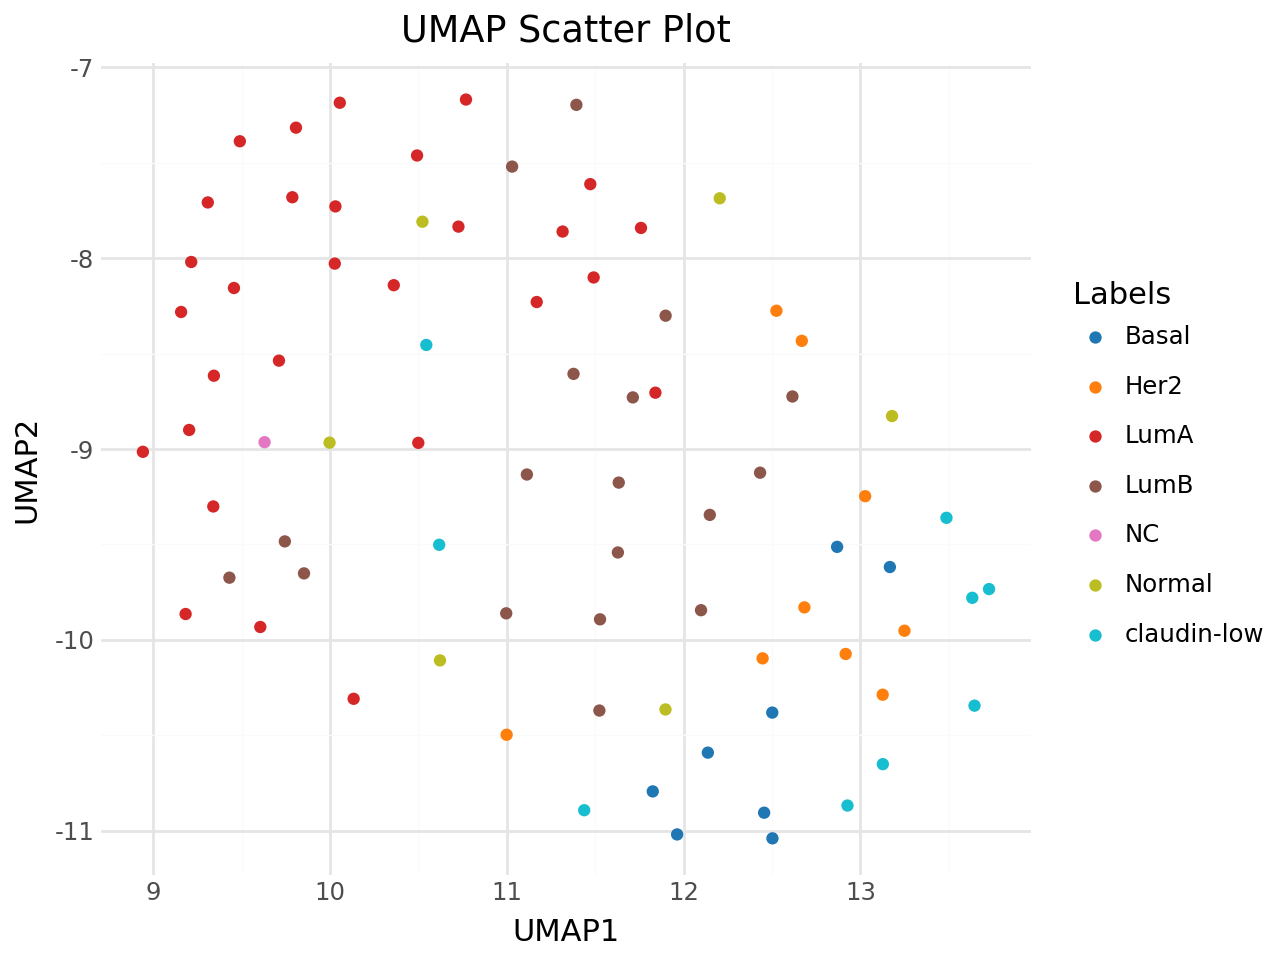

In [15]:
E_vae = model_vae.transform(test_dataset)
flexynesis.utils.plot_dim_reduced(E_vae, labels, method='umap', color_type='categorical')

## Section 4. supervised_vae — 비지도


> 파라미터 상세 설명 → [HyperparameterTuning Reference](https://cykim-saihst.github.io/flexynesis-workshop/hpo_guide.html)


Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 43, 'hidden_dim_factor': 0.2331422339394184, 'supervisor_hidden_dim': 17, 'lr': 0.00037538592368527556, 'epochs': 500, 'batch_size': 32}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │ 96.4 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │  3.7 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │  3.7 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │ 88.9 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │      0 │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 192 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 192 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 32                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

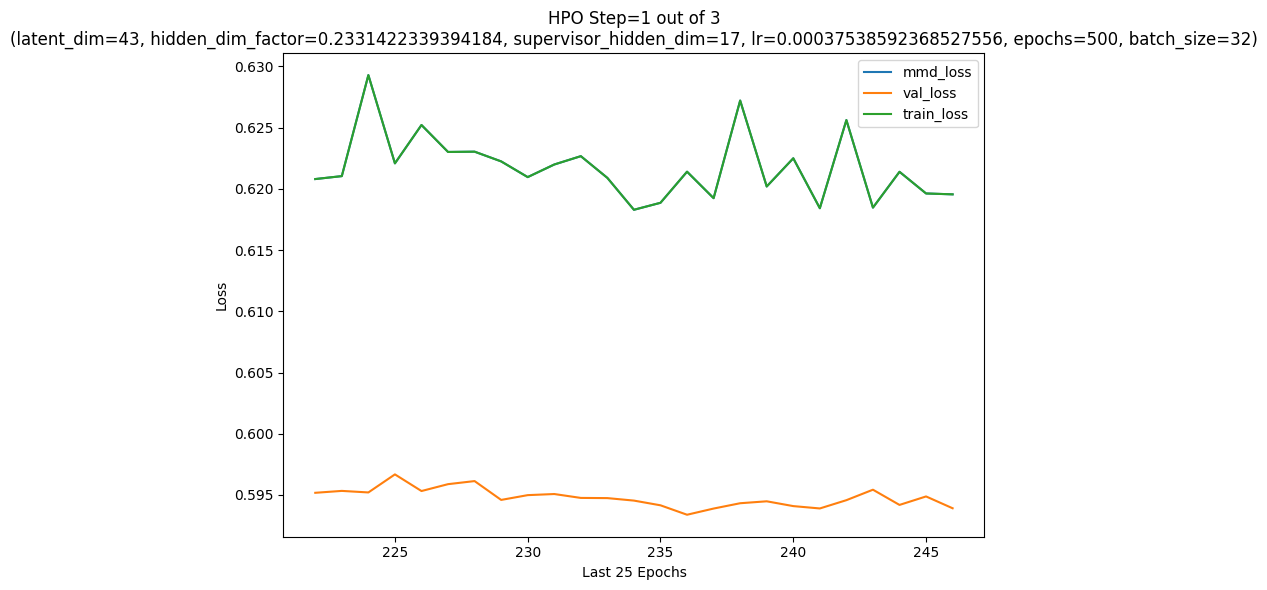

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         mmd_loss          │     0.594505786895752     │
│         val_loss          │     0.594505786895752     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [01:45<03:30, 105.15s/it, Iteration=1, Best Loss=0.595]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 0.594505786895752; best params: {'latent_dim': 43, 'hidden_dim_factor': 0.2331422339394184, 'supervisor_hidden_dim': 17, 'lr': 0.00037538592368527556, 'epochs': 500, 'batch_size': 32} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 18, 'hidden_dim_factor': 0.49631671692080953, 'supervisor_hidden_dim': 18, 'lr': 0.0005870205355800884, 'epochs': 500, 'batch_size': 128}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │  184 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │    666 │ train │     0 │
│ 3 │ FC_log_var │ Linear        │    666 │ train │     0 │
│ 4 │ decoders   │ ModuleList    │  178 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │      0 │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 364 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 364 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 32                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

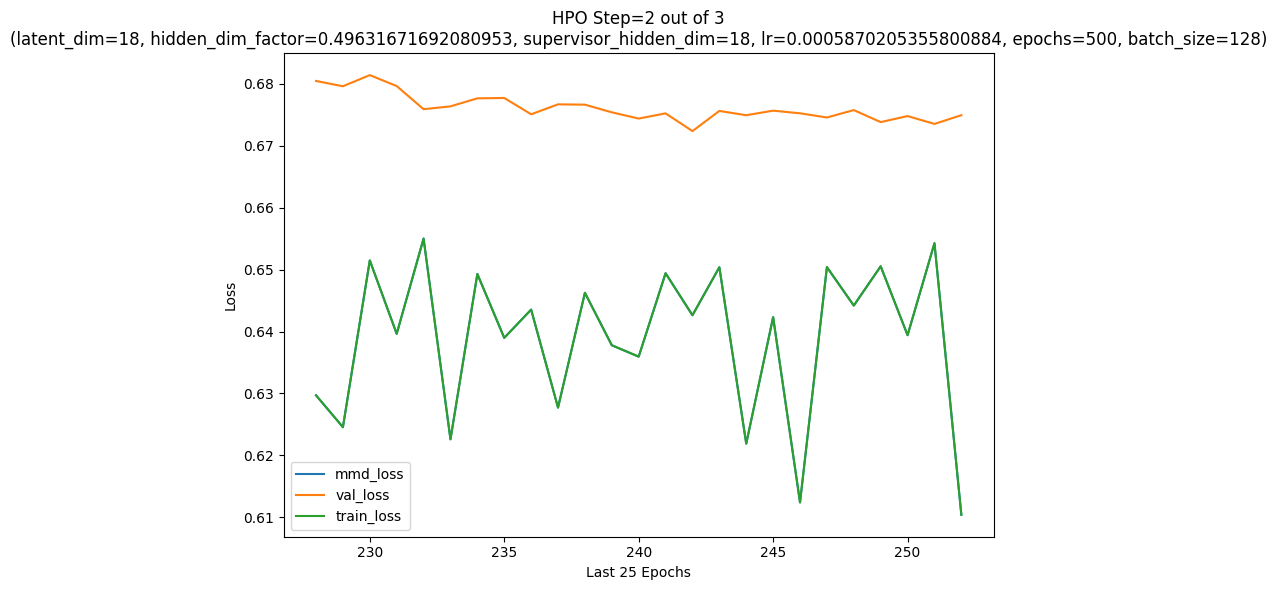

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         mmd_loss          │    0.6748475432395935     │
│         val_loss          │    0.6748475432395935     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [03:06<01:30, 90.88s/it, Iteration=2, Best Loss=0.595] GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 0.594505786895752; best params: {'latent_dim': 43, 'hidden_dim_factor': 0.2331422339394184, 'supervisor_hidden_dim': 17, 'lr': 0.00037538592368527556, 'epochs': 500, 'batch_size': 32} since 1 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 104, 'hidden_dim_factor': 0.22682330069367787, 'supervisor_hidden_dim': 18, 'lr': 0.005731081904472266, 'epochs': 500, 'batch_size': 64}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │  116 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │ 21.7 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │ 21.7 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │ 97.9 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │      0 │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 258 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 258 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 32                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

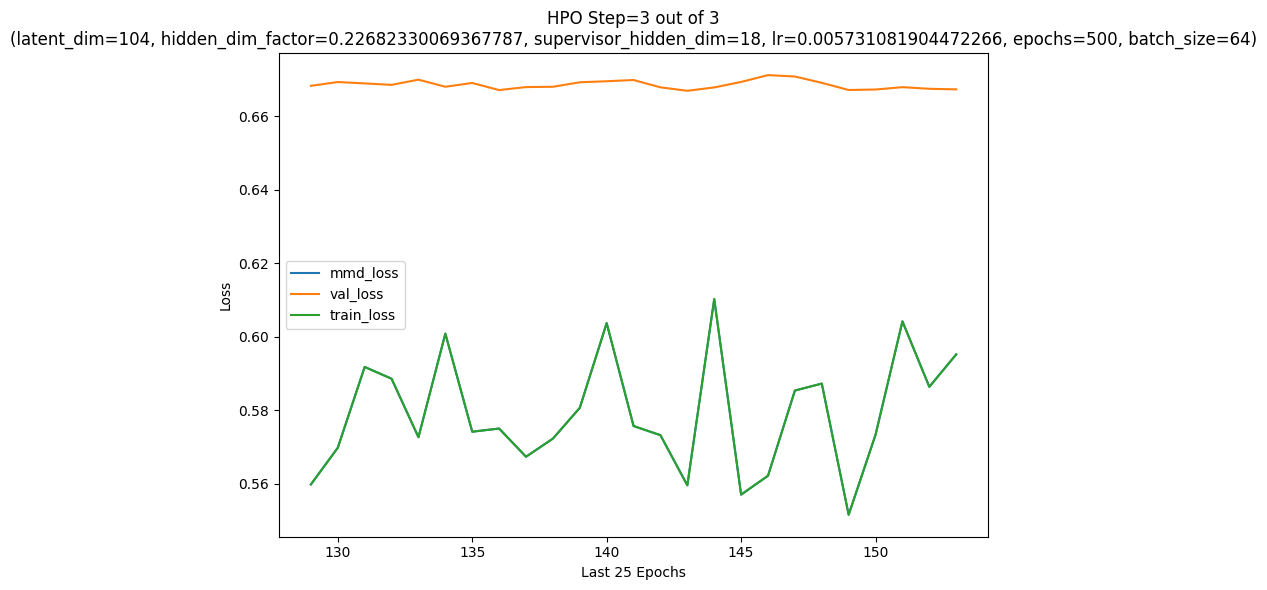

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         mmd_loss          │    0.6669526100158691     │
│         val_loss          │    0.6669526100158691     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [03:57<00:00, 79.02s/it, Iteration=3, Best Loss=0.595]

[INFO] current best val loss: 0.594505786895752; best params: {'latent_dim': 43, 'hidden_dim_factor': 0.2331422339394184, 'supervisor_hidden_dim': 17, 'lr': 0.00037538592368527556, 'epochs': 500, 'batch_size': 32} since 2 hpo iterations
소요 시간: 4.0분
저장: ./models/supervised_vae_unsup.pth


In [16]:
tuner = flexynesis.main.HyperparameterTuning(
    dataset=train_dataset,
    model_class=flexynesis.models.supervised_vae,
    target_variables=[],              # 비지도: supervisor head 없음
    config_name='supervised_vae',
    n_iter=HPO_ITER,
    val_size=0.2, use_cv=False, cv_splits=5,
    use_loss_weighting=True, early_stop_patience=10, plot_losses=True,
    surv_event_var=None, surv_time_var=None,
    batch_variables=None, device_type=None,
)
_t0 = time.time()
model_unsup, params_unsup = tuner.perform_tuning()
_elapsed = time.time() - _t0
training_log.append({'model': 'supervised_vae (unsup)', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f"소요 시간: {_elapsed/60:.1f}분")
torch.save(model_unsup, './models/supervised_vae_unsup.pth')
print("저장: ./models/supervised_vae_unsup.pth")

In [17]:
E_unsup = model_unsup.transform(test_dataset)

cluster_labels, G, partition = flexynesis.utils.louvain_clustering(E_unsup, k=10)
print("클러스터 수:", len(set(cluster_labels)))

scores = flexynesis.utils.compute_ami_ari(labels, cluster_labels)
print("AMI/ARI vs CLAUDIN_SUBTYPE:", scores)

클러스터 수: 8
AMI/ARI vs CLAUDIN_SUBTYPE: {'ami': 0.24825751180562572, 'ari': 0.16474503069557722}


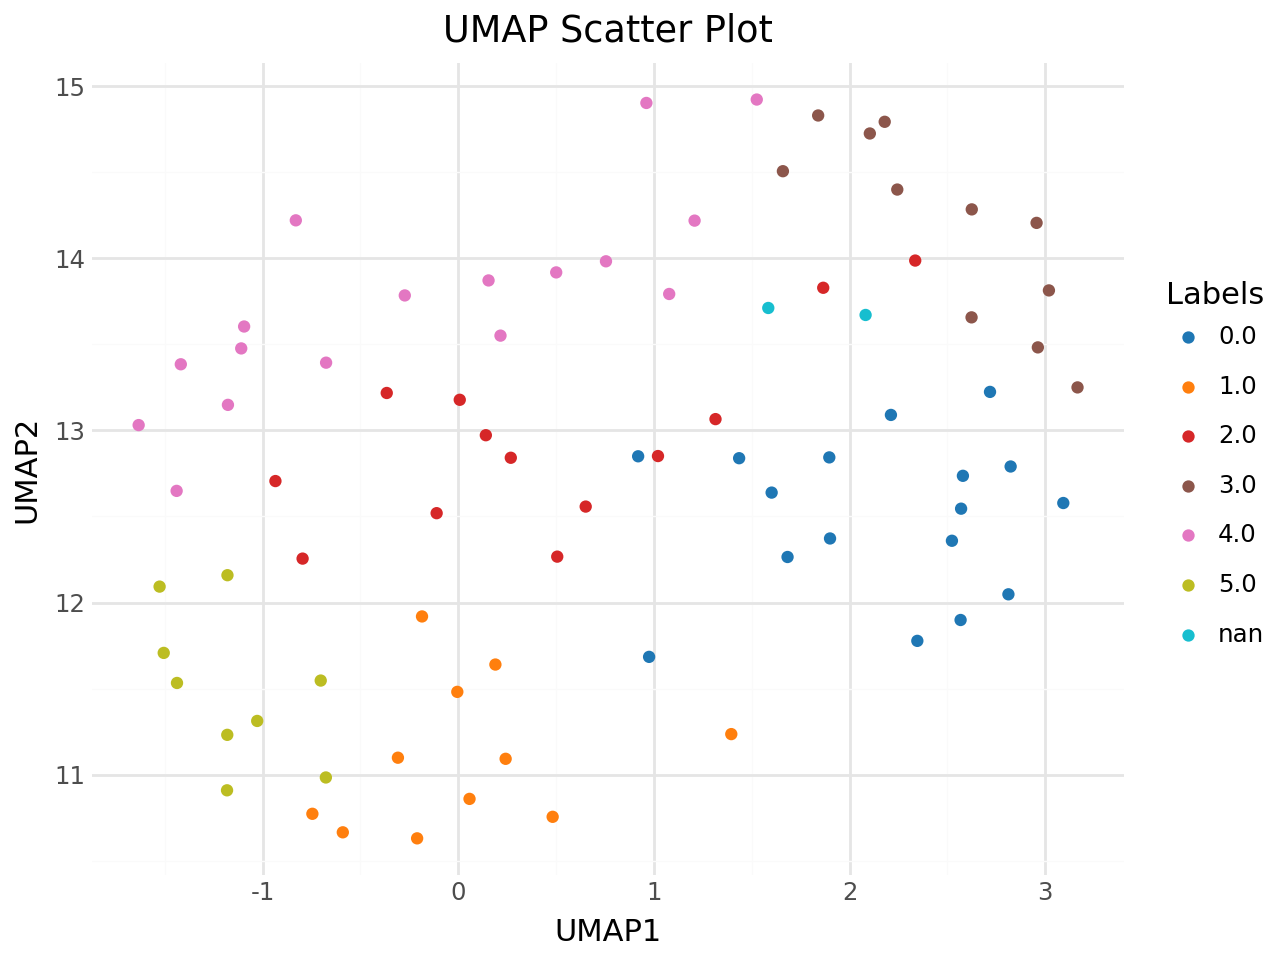

In [18]:
flexynesis.utils.plot_dim_reduced(E_unsup, cluster_labels, color_type='categorical', method='umap')

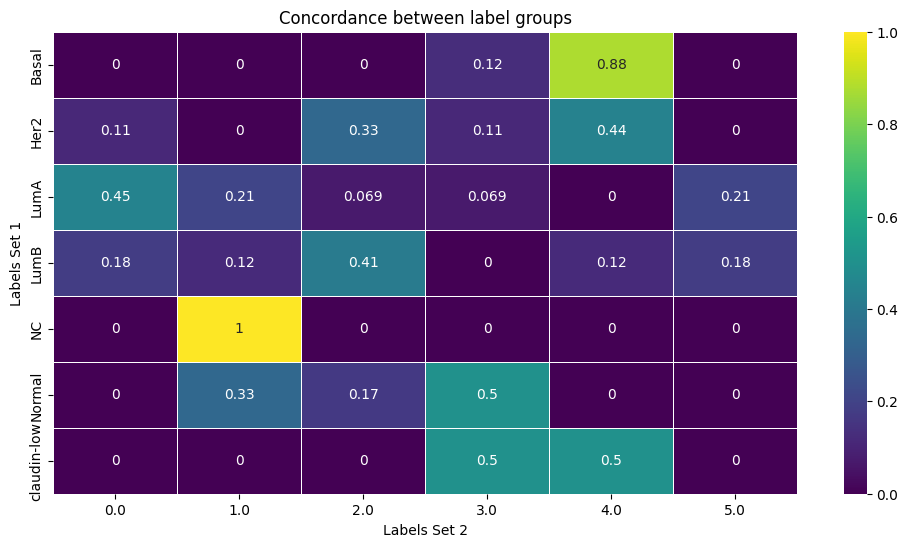

In [19]:
flexynesis.utils.plot_label_concordance_heatmap(labels, cluster_labels, figsize=(12, 6))

## Section 5. MultiTripletNetwork


> 파라미터 상세 설명 → [HyperparameterTuning Reference](https://cykim-saihst.github.io/flexynesis-workshop/hpo_guide.html)


In [20]:
# ── MultiTripletNetwork ─────────────────────────────────────
# 1) TripletDataset 로딩 테스트
from flexynesis.data import TripletMultiOmicDataset
from torch.utils.data import DataLoader, random_split
import time

print('TripletMultiOmicDataset 생성 중...')
t0 = time.time()
triplet_ds = TripletMultiOmicDataset(train_dataset, 'CLAUDIN_SUBTYPE')
print(f'  완료 ({time.time()-t0:.1f}s), len={len(triplet_ds)}')

# 클래스별 샘플 수 확인 (1개 클래스=infinite loop)
import numpy as np
labels = train_dataset.ann['CLAUDIN_SUBTYPE'].numpy()
unique, counts = np.unique(labels, return_counts=True)
print('클래스별 샘플 수:', dict(zip(unique.tolist(), counts.tolist())))
assert all(c >= 2 for c in counts), 'ERROR: 1개짜리 클래스 있음 → infinite loop!'

# 2) DataLoader 배치 1개 로딩 테스트
print('\nDataLoader 배치 테스트...')
t0 = time.time()
loader = DataLoader(triplet_ds, batch_size=16, num_workers=0, pin_memory=False)
batch = next(iter(loader))
print(f'  완료 ({time.time()-t0:.1f}s), batch keys: anchor={list(batch[0].keys())}')
print('통과! DataLoader 정상')

TripletMultiOmicDataset 생성 중...
  완료 (0.0s), len=199
클래스별 샘플 수: {0.0: 22, 1.0: 23, 2.0: 71, 3.0: 50, 4.0: 2, 5.0: 14, 6.0: 17}

DataLoader 배치 테스트...
  완료 (0.0s), batch keys: anchor=['cna', 'gex']
통과! DataLoader 정상


Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 94, 'hidden_dim_factor': 0.20182662447195174, 'supervisor_hidden_dim': 10, 'lr': 0.005468755467461021, 'epochs': 500, 'batch_size': 32}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │ 84.7 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │ 17.8 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  1.0 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 103 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 103 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

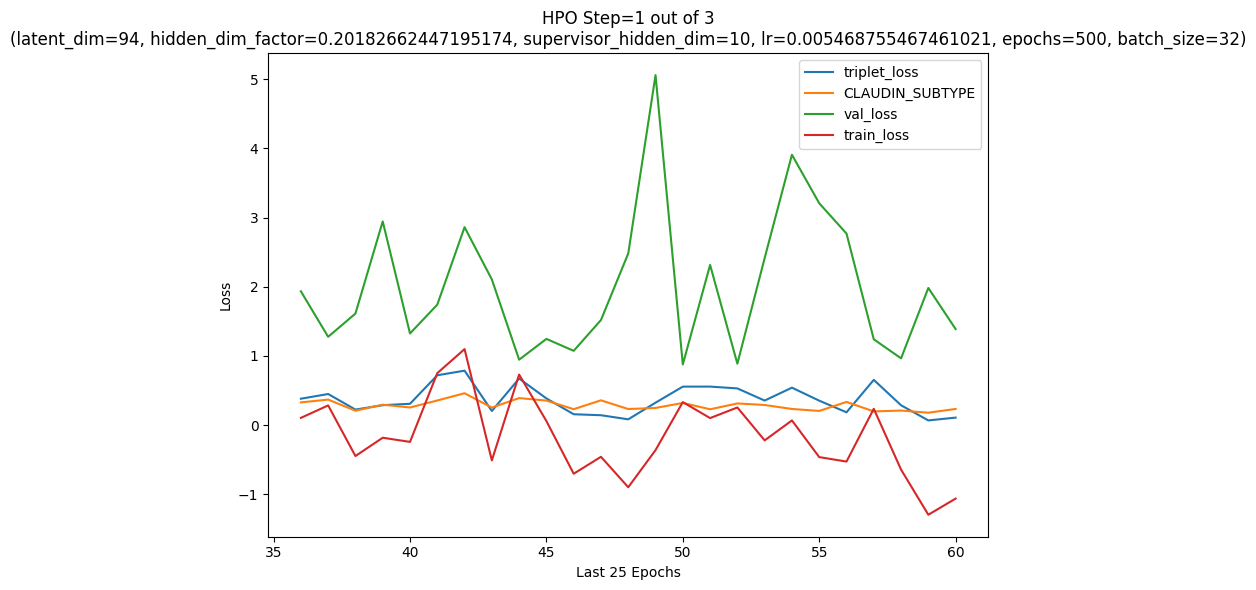

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.9480093121528625     │
│       triplet_loss        │    0.5201254487037659     │
│         val_loss          │    1.4681347608566284     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [00:31<01:02, 31.04s/it, Iteration=1, Best Loss=1.47]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 1.4681347608566284; best params: {'latent_dim': 94, 'hidden_dim_factor': 0.20182662447195174, 'supervisor_hidden_dim': 10, 'lr': 0.005468755467461021, 'epochs': 500, 'batch_size': 32} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 110, 'hidden_dim_factor': 0.2726693653473701, 'supervisor_hidden_dim': 19, 'lr': 0.00019516099595990124, 'epochs': 500, 'batch_size': 128}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │  117 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │ 24.3 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │  2.3 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 144 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 144 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

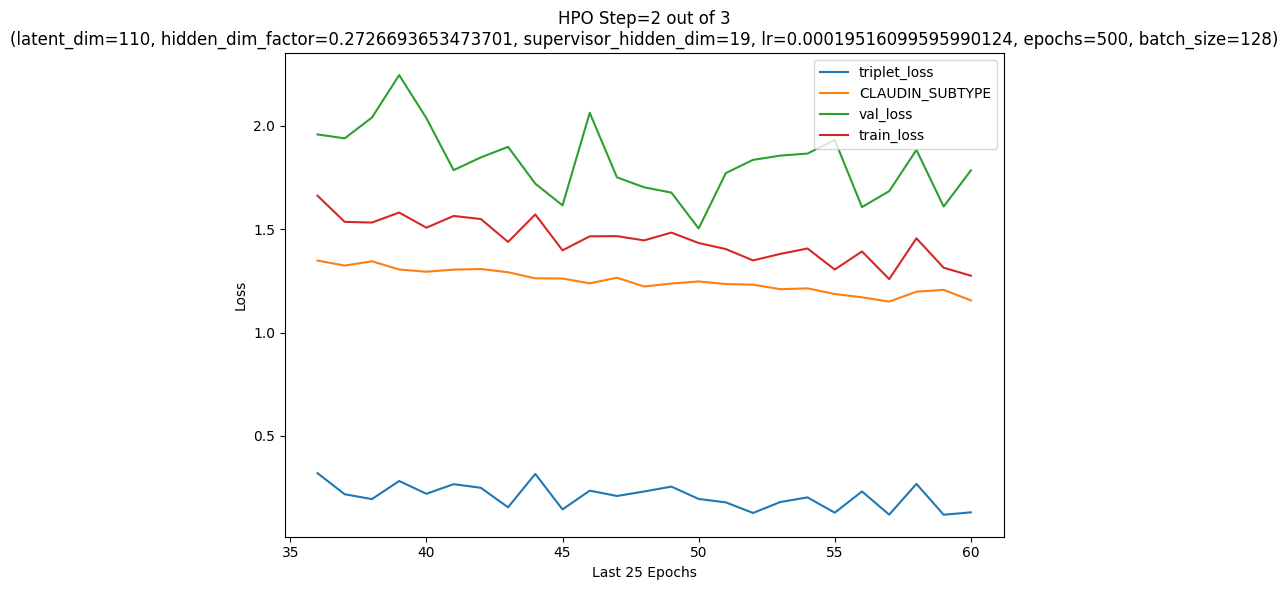

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.4608136415481567     │
│       triplet_loss        │    0.39578530192375183    │
│         val_loss          │    1.8565988540649414     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [00:53<00:25, 25.95s/it, Iteration=2, Best Loss=1.47]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 1.4681347608566284; best params: {'latent_dim': 94, 'hidden_dim_factor': 0.20182662447195174, 'supervisor_hidden_dim': 10, 'lr': 0.005468755467461021, 'epochs': 500, 'batch_size': 32} since 1 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 40, 'hidden_dim_factor': 0.45902023005710063, 'supervisor_hidden_dim': 18, 'lr': 0.0003846185109296146, 'epochs': 500, 'batch_size': 32}


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars     │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders     │ ModuleList    │  172 K │ train │     0 │
│ 2 │ fusion_block │ Linear        │  3.2 K │ train │     0 │
│ 3 │ MLPs         │ ModuleDict    │    907 │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 176 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 176 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 22                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

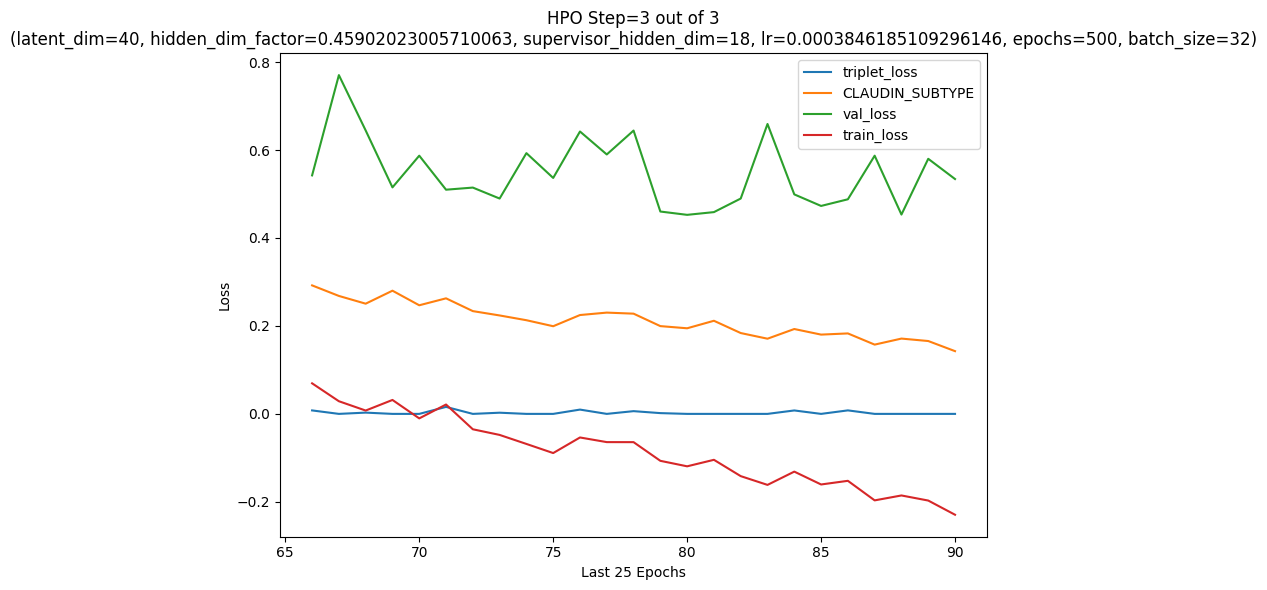

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.4472220540046692     │
│       triplet_loss        │    0.11326034367084503    │
│         val_loss          │    0.5604824423789978     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [01:42<00:00, 34.26s/it, Iteration=3, Best Loss=0.56]

[INFO] current best val loss: 0.5604824423789978; best params: {'latent_dim': 40, 'hidden_dim_factor': 0.45902023005710063, 'supervisor_hidden_dim': 18, 'lr': 0.0003846185109296146, 'epochs': 500, 'batch_size': 32} since 0 hpo iterations
소요 시간: 1.7분
저장: ./models/MultiTripletNetwork.pth


In [21]:
tuner = flexynesis.main.HyperparameterTuning(
    dataset=train_dataset,
    model_class=flexynesis.models.MultiTripletNetwork,
    target_variables=['CLAUDIN_SUBTYPE'],
    config_name='MultiTripletNetwork',
    n_iter=HPO_ITER,
    val_size=0.2, use_cv=False, cv_splits=5,
    use_loss_weighting=True, early_stop_patience=10, plot_losses=True,
    surv_event_var=None, surv_time_var=None,
    batch_variables=None, device_type=None,              
)
_t0 = time.time()
model_tri, params_tri = tuner.perform_tuning()
_elapsed = time.time() - _t0
training_log.append({'model': 'MultiTripletNetwork', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f"소요 시간: {_elapsed/60:.1f}분")
torch.save(model_tri, './models/MultiTripletNetwork.pth')
print("저장: ./models/MultiTripletNetwork.pth")

In [22]:
metrics_tri = flexynesis.utils.evaluate_wrapper(
    method='MultiTripletNetwork',
    y_pred_dict=model_tri.predict(test_dataset),
    dataset=test_dataset,
)
all_metrics.append(metrics_tri)
metrics_tri

,method,var,variable_type,metric,value
0,MultiTripletNetwork,CLAUDIN_SUBTYPE,categorical,balanced_acc,0.524973
1,MultiTripletNetwork,CLAUDIN_SUBTYPE,categorical,f1_score,0.666434
2,MultiTripletNetwork,CLAUDIN_SUBTYPE,categorical,kappa,0.587629
3,MultiTripletNetwork,CLAUDIN_SUBTYPE,categorical,average_auroc,0.927117
4,MultiTripletNetwork,CLAUDIN_SUBTYPE,categorical,average_aupr,0.803102


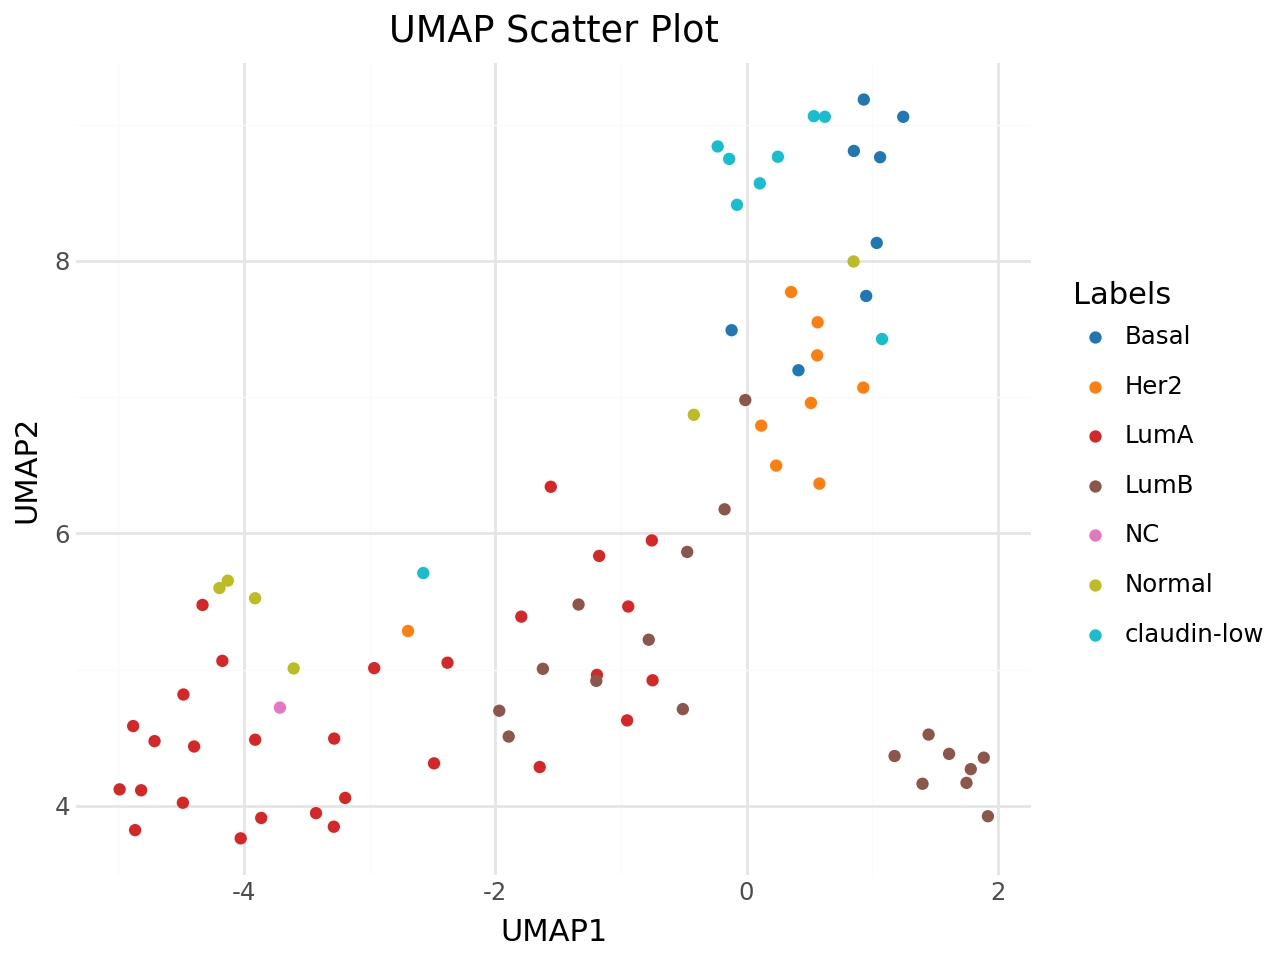

In [23]:
E_tri = model_tri.transform(test_dataset)
labels_tri = [test_dataset.label_mappings['CLAUDIN_SUBTYPE'][x]
              for x in test_dataset.ann['CLAUDIN_SUBTYPE'].numpy()]
flexynesis.utils.plot_dim_reduced(E_tri, labels_tri, color_type='categorical', method='umap')

## Section 6. GNN


> 파라미터 상세 설명 → [HyperparameterTuning Reference](https://cykim-saihst.github.io/flexynesis-workshop/hpo_guide.html)


In [24]:
from flexynesis.data import STRING, MultiOmicDatasetNW

data_importer_gnn = flexynesis.data.DataImporter(
    path=PATH,
    data_types=['gex'],                # GNN은 gex만 사용
    concatenate=False,
    top_percentile=10, min_features=50,
    correlation_threshold=0.9, variance_threshold=0.8,
    na_threshold=0.1, log_transform=False,
    covariates=None, downsample=0, restrict_to_features=None,
)
train_gnn_raw, test_gnn_raw = data_importer_gnn.import_data()


[INFO] ================= Importing Data =================
[INFO] Validating data folders...

[INFO] ----------------- Reading Data ----------------- 
[INFO] Importing /data01/storage/flexynesis_workshop/brca_mini/train/clin.csv...
[INFO] Importing /data01/storage/flexynesis_workshop/brca_mini/train/gex.csv...

[INFO] ----------------- Reading Data ----------------- 
[INFO] Importing /data01/storage/flexynesis_workshop/brca_mini/test/clin.csv...
[INFO] Importing /data01/storage/flexynesis_workshop/brca_mini/test/gex.csv...

[INFO] ----------------- Checking for problems with the input data ----------------- 
[INFO] Data structure is valid with no errors or warnings.

[INFO] ----------------- Processing Data (train) ----------------- 

[INFO] ----------------- Cleaning Up Data ----------------- 

[INFO] working on layer:  gex
[INFO] Imputing NA values to median of features, affected # of cells in the matrix 2  # of rows: 2
[INFO] Number of NA values:  0
[INFO] DataFrame gex - Removed 16

Filtering redundant features: 100%|██████████| 412/412 [00:00<00:00, 5093.73it/s]



[INFO] ----------------- Processing Data (test) ----------------- 

[INFO] ----------------- Cleaning Up Data ----------------- 

[INFO] working on layer:  gex
[INFO] Number of NA values:  0
[INFO] DataFrame gex - Removed 16482 features.
[INFO] DataFrame gex - Removed 0 samples (0.00%).

[INFO] ----------------- Harmonizing Data Sets ----------------- 

[INFO] ----------------- Finished Harmonizing ----------------- 

[INFO] ----------------- Normalizing Data ----------------- 

[INFO] ----------------- Normalizing Data ----------------- 
[INFO] Training Data Stats:  {'feature_count in: gex': 369, 'sample_count': 200}
[INFO] Test Data Stats:  {'feature_count in: gex': 369, 'sample_count': 80}
[INFO] Merging Feature Logs...
[INFO] Data import successful.


In [25]:
# STRING DB 자동 다운로드 (첫 실행 후 ~/.cache/flexynesis/STRING/ 에 캐시)
print("STRING DB 로딩 중...")
string_obj = STRING(organism=9606, node_name='gene_name')
graph_df   = string_obj.graph_df
print(f"PPI interactions: {len(graph_df)}")

train_gnn = MultiOmicDatasetNW(train_gnn_raw, graph_df, modality_order=['gex'])
test_gnn  = MultiOmicDatasetNW(test_gnn_raw,  graph_df, modality_order=['gex'])
train_gnn.print_stats()

STRING DB 로딩 중...
PPI interactions: 95229
Dataset Statistics:
Number of nodes: 354
Total number of edges: 134
Number of node features per node: 1
Number of singletons (nodes with no edges): 225
Mean number of edges per node (excluding singletons): 2.08
Median number of edges per node (excluding singletons): 2
Max number of edges per node: 11


Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 17, 'node_embedding_dim': 26, 'num_convs': 3, 'lr': 0.0005586111526131259, 'supervisor_hidden_dim': 9, 'epochs': 500, 'activation': 'relu', 'batch_size': 128}


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders │ ModuleList    │  159 K │ train │     0 │
│ 2 │ MLPs     │ ModuleDict    │    250 │ train │     0 │
└───┴──────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 159 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 159 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

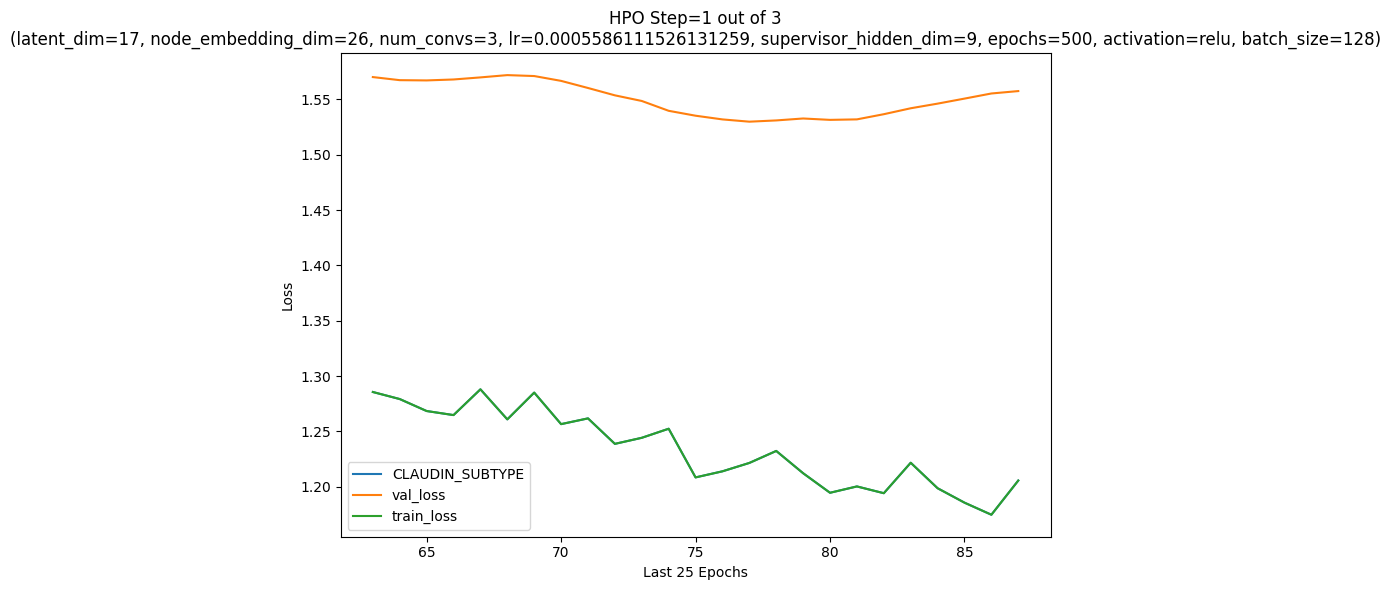

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │     1.557491660118103     │
│         val_loss          │     1.557491660118103     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [00:19<00:39, 19.70s/it, Iteration=1, Best Loss=1.56]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 1.557491660118103; best params: {'latent_dim': 17, 'node_embedding_dim': 26, 'num_convs': 3, 'lr': 0.0005586111526131259, 'supervisor_hidden_dim': 9, 'epochs': 500, 'activation': 'relu', 'batch_size': 128} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 77, 'node_embedding_dim': 30, 'num_convs': 2, 'lr': 0.0028278203840949715, 'supervisor_hidden_dim': 23, 'epochs': 500, 'activation': 'relu', 'batch_size': 64}


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders │ ModuleList    │  819 K │ train │     0 │
│ 2 │ MLPs     │ ModuleDict    │  2.0 K │ train │     0 │
└───┴──────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 821 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 821 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

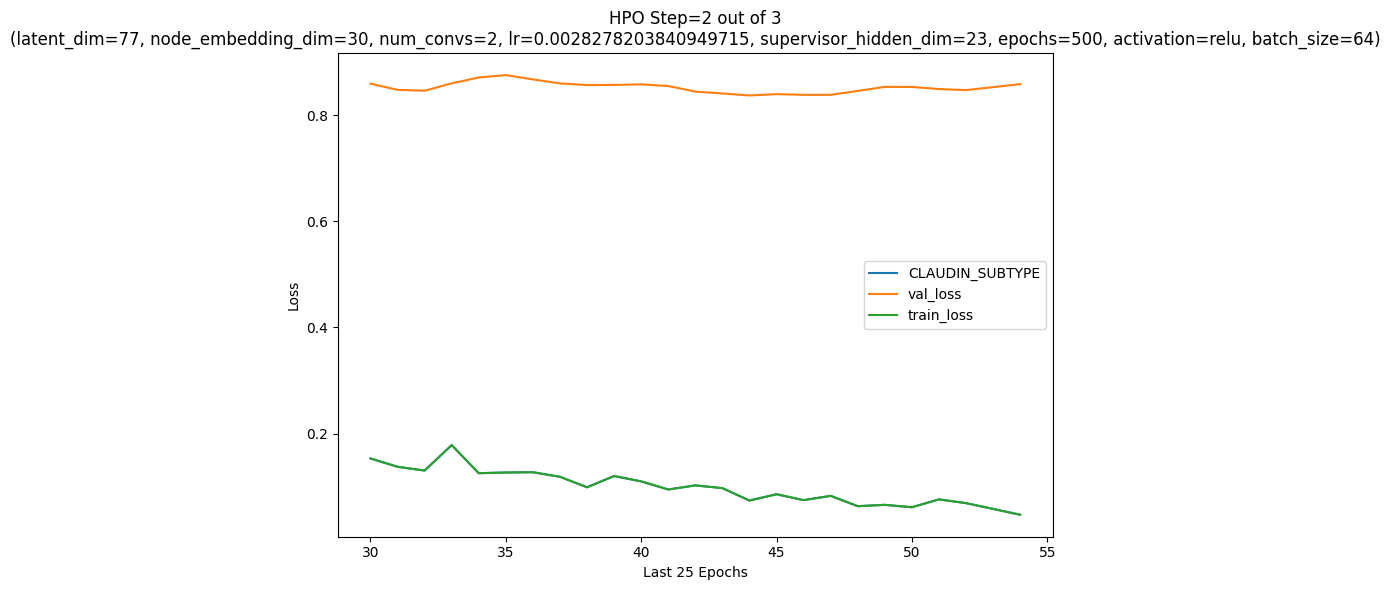

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.8580913543701172     │
│         val_loss          │    0.8580913543701172     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [00:37<00:18, 18.41s/it, Iteration=2, Best Loss=0.858]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 0.8580913543701172; best params: {'latent_dim': 77, 'node_embedding_dim': 30, 'num_convs': 2, 'lr': 0.0028278203840949715, 'supervisor_hidden_dim': 23, 'epochs': 500, 'activation': 'relu', 'batch_size': 64} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 72, 'node_embedding_dim': 25, 'num_convs': 2, 'lr': 0.006027178462153539, 'supervisor_hidden_dim': 10, 'epochs': 500, 'activation': 'relu', 'batch_size': 128}


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars │ ParameterDict │      1 │ train │     0 │
│ 1 │ encoders │ ModuleList    │  638 K │ train │     0 │
│ 2 │ MLPs     │ ModuleDict    │    827 │ train │     0 │
└───┴──────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 639 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 639 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

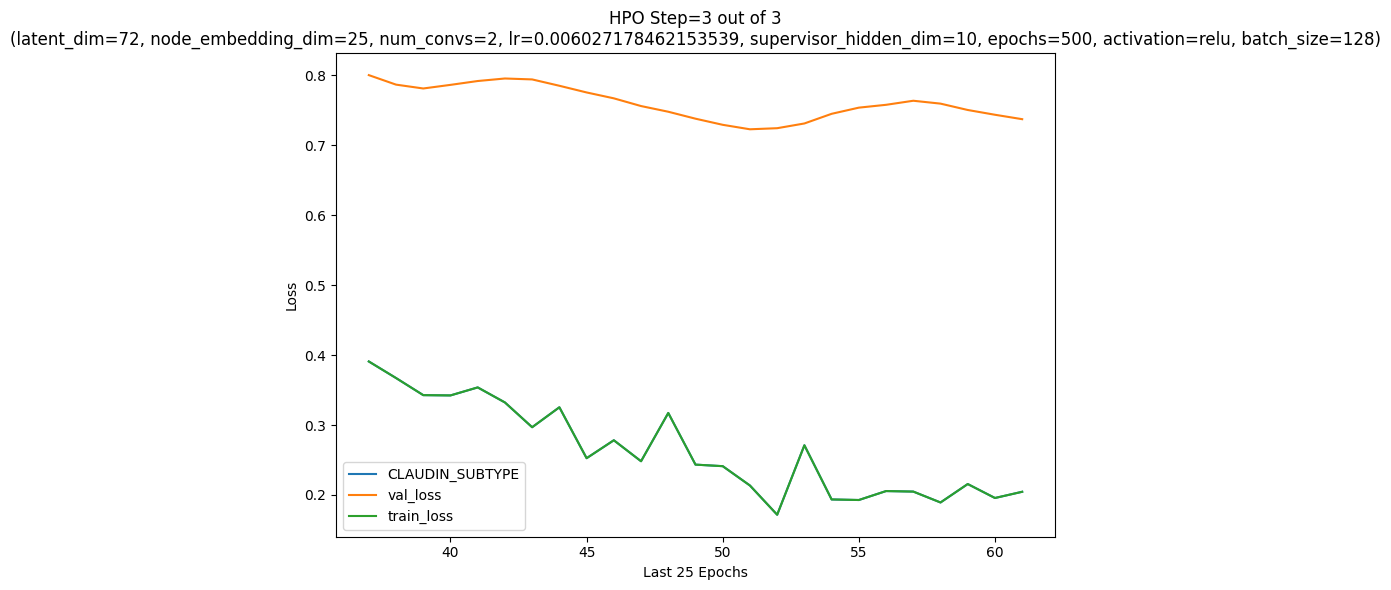

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.7374961972236633     │
│         val_loss          │    0.7374961972236633     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [00:56<00:00, 18.90s/it, Iteration=3, Best Loss=0.737]

[INFO] current best val loss: 0.7374961972236633; best params: {'latent_dim': 72, 'node_embedding_dim': 25, 'num_convs': 2, 'lr': 0.006027178462153539, 'supervisor_hidden_dim': 10, 'epochs': 500, 'activation': 'relu', 'batch_size': 128} since 0 hpo iterations
소요 시간: 0.9분
저장: ./models/GNN.pth


In [26]:
tuner = flexynesis.main.HyperparameterTuning(
    dataset=train_gnn,
    model_class=flexynesis.models.GNN,
    target_variables=['CLAUDIN_SUBTYPE'],
    config_name='GNN',
    n_iter=HPO_ITER,
    val_size=0.2, use_cv=False, cv_splits=5,
    use_loss_weighting=True, early_stop_patience=10, plot_losses=True,
    surv_event_var=None, surv_time_var=None,
    batch_variables=None, device_type=None,
    gnn_conv_type='GC',                # 'GC'(기본), 'GCN', 'GAT', 'SAGE'
)
_t0 = time.time()
model_gnn, params_gnn = tuner.perform_tuning()
_elapsed = time.time() - _t0
training_log.append({'model': 'GNN', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f"소요 시간: {_elapsed/60:.1f}분")
torch.save(model_gnn, './models/GNN.pth')
print("저장: ./models/GNN.pth")

In [27]:
metrics_gnn = flexynesis.utils.evaluate_wrapper(
    method='GNN',
    y_pred_dict=model_gnn.predict(test_gnn),
    dataset=test_gnn,
)
all_metrics.append(metrics_gnn)
metrics_gnn

,method,var,variable_type,metric,value
0,GNN,CLAUDIN_SUBTYPE,categorical,balanced_acc,0.554871
1,GNN,CLAUDIN_SUBTYPE,categorical,f1_score,0.685037
2,GNN,CLAUDIN_SUBTYPE,categorical,kappa,0.597342
3,GNN,CLAUDIN_SUBTYPE,categorical,average_auroc,0.928055
4,GNN,CLAUDIN_SUBTYPE,categorical,average_aupr,0.772502


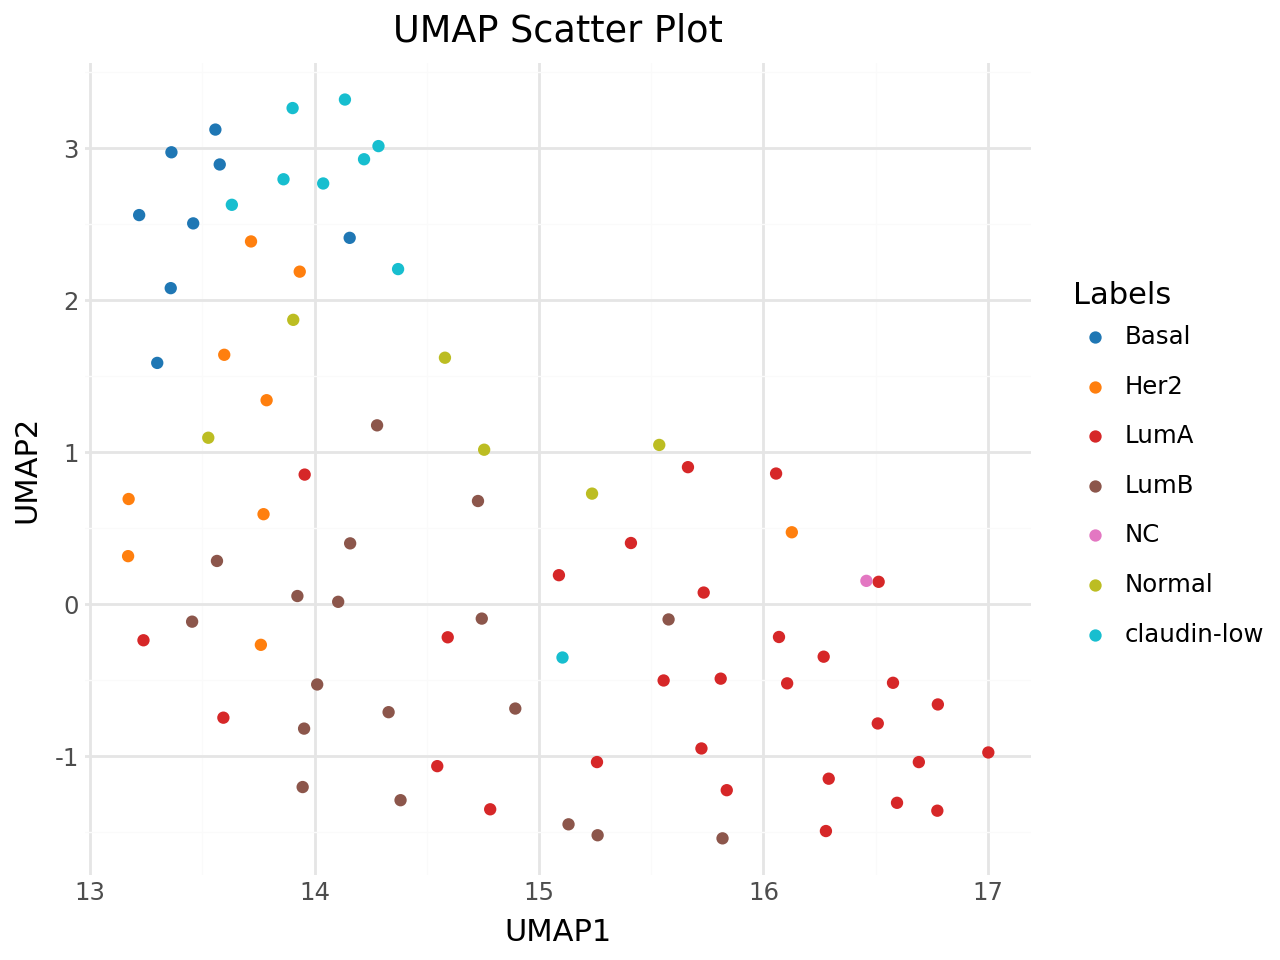

In [28]:
E_gnn = model_gnn.transform(test_gnn)
labels_gnn = [test_gnn.label_mappings['CLAUDIN_SUBTYPE'][x]
              for x in test_gnn.ann['CLAUDIN_SUBTYPE'].numpy()]
flexynesis.utils.plot_dim_reduced(E_gnn, labels_gnn, color_type='categorical', method='umap')

## Section 7. CrossModalPred


> 파라미터 상세 설명 → [HyperparameterTuning Reference](https://cykim-saihst.github.io/flexynesis-workshop/hpo_guide.html)


Tuning Progress:   0%|          | 0/3 [00:00<?, ?it/s]/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cykim/miniforge3/envs/flexy/lib/python3.12/sit ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 112, 'hidden_dim_factor': 0.2495906858413884, 'supervisor_hidden_dim': 29, 'lr': 0.0009583629450092886, 'epochs': 500, 'batch_size': 128}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │ 55.2 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │ 12.7 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │ 12.7 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │ 63.8 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │  3.5 K │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 147 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 147 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/cykim/miniforge3/envs/flexy/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

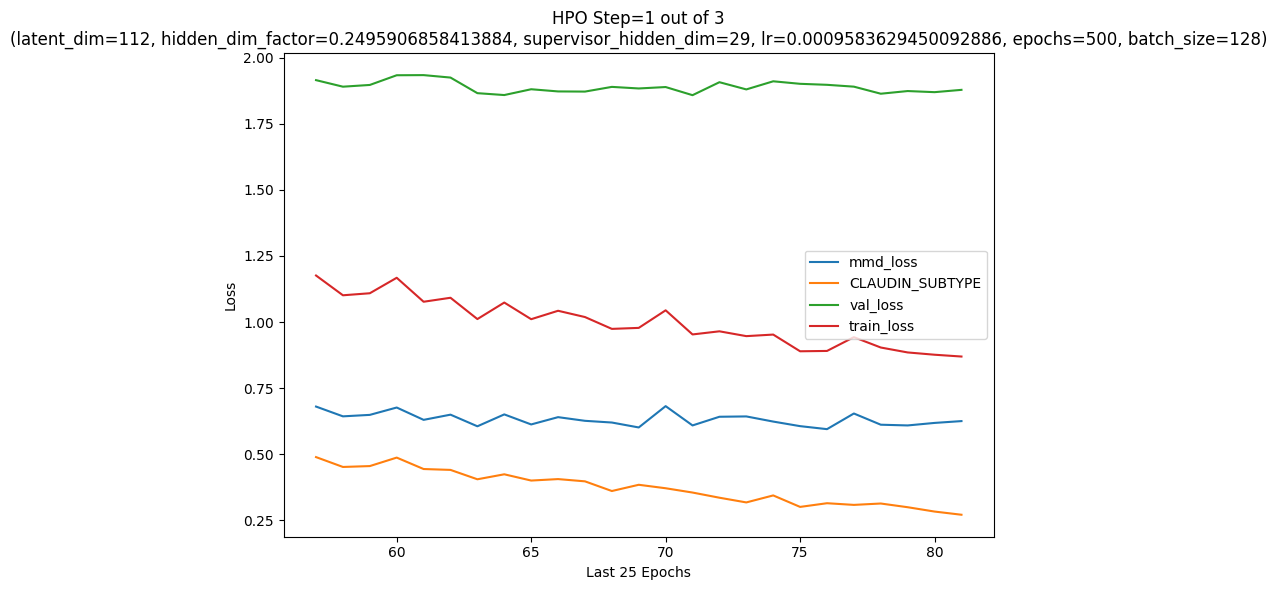

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.8558371067047119     │
│         mmd_loss          │    1.0313940048217773     │
│         val_loss          │    1.8872311115264893     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  33%|███▎      | 1/3 [00:24<00:48, 24.23s/it, Iteration=1, Best Loss=1.89]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 1.8872311115264893; best params: {'latent_dim': 112, 'hidden_dim_factor': 0.2495906858413884, 'supervisor_hidden_dim': 29, 'lr': 0.0009583629450092886, 'epochs': 500, 'batch_size': 128} since 0 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 84, 'hidden_dim_factor': 0.37298420213891537, 'supervisor_hidden_dim': 21, 'lr': 0.0005525085868653468, 'epochs': 500, 'batch_size': 32}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │ 75.0 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │  7.1 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │  7.1 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │ 90.8 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │  2.0 K │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 182 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 182 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

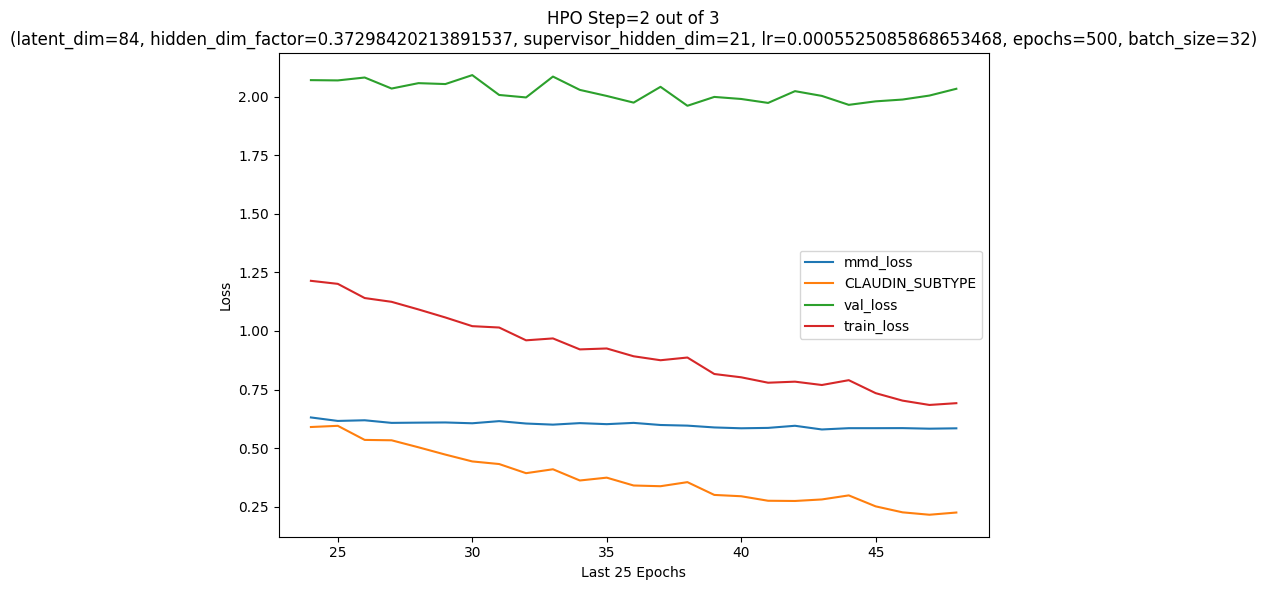

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    0.9851507544517517     │
│         mmd_loss          │    0.9967672824859619     │
│         val_loss          │    1.9819179773330688     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress:  67%|██████▋   | 2/3 [00:48<00:24, 24.16s/it, Iteration=2, Best Loss=1.89]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


[INFO] current best val loss: 1.8872311115264893; best params: {'latent_dim': 112, 'hidden_dim_factor': 0.2495906858413884, 'supervisor_hidden_dim': 29, 'lr': 0.0009583629450092886, 'epochs': 500, 'batch_size': 128} since 1 hpo iterations
[INFO] training validation split 1
[INFO] hpo config:{'latent_dim': 121, 'hidden_dim_factor': 0.4681955615140883, 'supervisor_hidden_dim': 16, 'lr': 0.002876918372105493, 'epochs': 500, 'batch_size': 64}


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ log_vars   │ ParameterDict │      2 │ train │     0 │
│ 1 │ encoders   │ ModuleList    │  106 K │ train │     0 │
│ 2 │ FC_mean    │ Linear        │ 14.8 K │ train │     0 │
│ 3 │ FC_log_var │ Linear        │ 14.8 K │ train │     0 │
│ 4 │ decoders   │ ModuleList    │  121 K │ train │     0 │
│ 5 │ MLPs       │ ModuleDict    │  2.1 K │ train │     0 │
└───┴────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 260 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 260 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

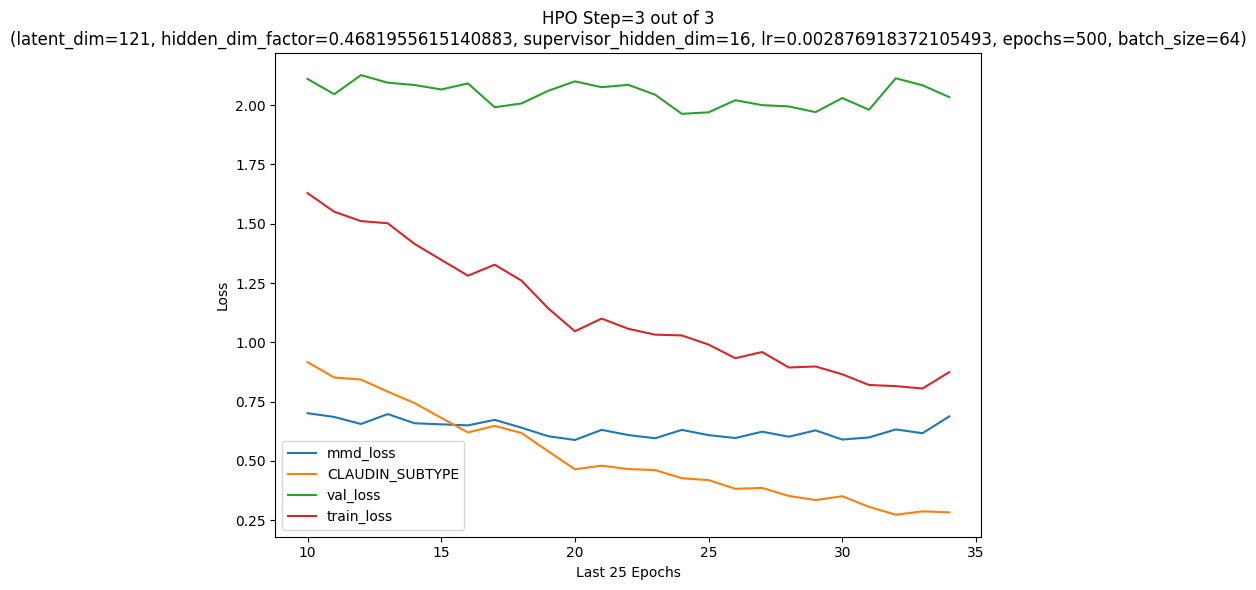

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      CLAUDIN_SUBTYPE      │    1.1695882081985474     │
│         mmd_loss          │    0.8548206686973572     │
│         val_loss          │    2.0244088172912598     │
└───────────────────────────┴───────────────────────────┘

Tuning Progress: 100%|██████████| 3/3 [01:00<00:00, 20.18s/it, Iteration=3, Best Loss=1.89]

[INFO] current best val loss: 1.8872311115264893; best params: {'latent_dim': 112, 'hidden_dim_factor': 0.2495906858413884, 'supervisor_hidden_dim': 29, 'lr': 0.0009583629450092886, 'epochs': 500, 'batch_size': 128} since 2 hpo iterations
소요 시간: 1.0분
저장: ./models/CrossModalPred.pth


In [29]:
tuner = flexynesis.main.HyperparameterTuning(
    dataset=train_dataset,
    model_class=flexynesis.models.CrossModalPred,
    target_variables=['CLAUDIN_SUBTYPE'],
    config_name='CrossModalPred',
    n_iter=HPO_ITER,
    val_size=0.2, use_cv=False, cv_splits=5,
    use_loss_weighting=True, early_stop_patience=10, plot_losses=True,
    surv_event_var=None, surv_time_var=None,
    batch_variables=None, device_type=None,
    input_layers=['gex'],              # 입력 omics
    output_layers=['cna'],             # 재구성 대상 omics
)
_t0 = time.time()
model_cross, params_cross = tuner.perform_tuning()
_elapsed = time.time() - _t0
training_log.append({'model': 'CrossModalPred', 'time_sec': _elapsed, 'hpo_iter': HPO_ITER})
print(f"소요 시간: {_elapsed/60:.1f}분")
torch.save(model_cross, './models/CrossModalPred.pth')
print("저장: ./models/CrossModalPred.pth")

In [30]:
metrics_cross = flexynesis.utils.evaluate_wrapper(
    method='CrossModalPred',
    y_pred_dict=model_cross.predict(test_dataset),
    dataset=test_dataset,
)
all_metrics.append(metrics_cross)
metrics_cross

,method,var,variable_type,metric,value
0,CrossModalPred,CLAUDIN_SUBTYPE,categorical,balanced_acc,0.522989
1,CrossModalPred,CLAUDIN_SUBTYPE,categorical,f1_score,0.666793
2,CrossModalPred,CLAUDIN_SUBTYPE,categorical,kappa,0.591920
3,CrossModalPred,CLAUDIN_SUBTYPE,categorical,average_auroc,0.923303
4,CrossModalPred,CLAUDIN_SUBTYPE,categorical,average_aupr,0.801825


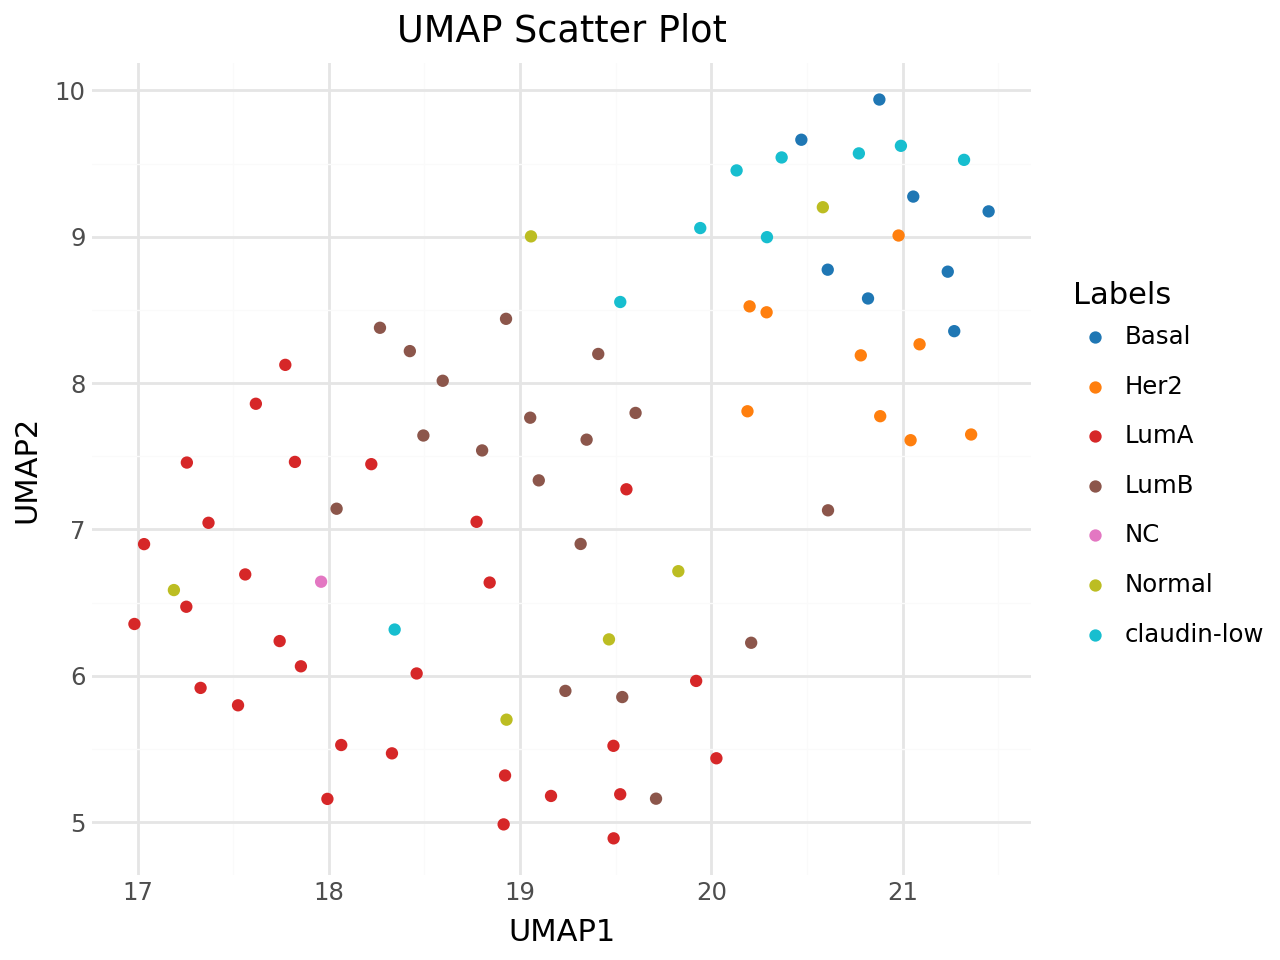

In [31]:
E_cross = model_cross.transform(test_dataset)
labels_cross = [test_dataset.label_mappings['CLAUDIN_SUBTYPE'][x]
                for x in test_dataset.ann['CLAUDIN_SUBTYPE'].numpy()]
flexynesis.utils.plot_dim_reduced(E_cross, labels_cross, color_type='categorical', method='umap')

## Section 8. 모델 성능 비교


> 평가 지표 설명 → [Evaluation Metrics](https://cykim-saihst.github.io/flexynesis-workshop/evaluation.html)


In [32]:
log_df = pd.DataFrame(training_log)
log_df['time_min'] = (log_df['time_sec'] / 60).round(1)
log_df['time_sec'] = log_df['time_sec'].round(0).astype(int)
log_df = log_df[['model', 'hpo_iter', 'time_min', 'time_sec']]
log_df.columns = ['Model', 'HPO iter', 'Time (min)', 'Time (sec)']
log_df

,Model,HPO iter,Time (min),Time (sec)
0,DirectPred (clf),3,0.7,43
1,DirectPred (surv),3,0.3,19
2,supervised_vae (clf),3,1.3,81
3,supervised_vae (unsup),3,4.0,237
4,MultiTripletNetwork,3,1.7,103
5,GNN,3,0.9,57
6,CrossModalPred,3,1.0,61


In [33]:
clf_metrics = [m for m in all_metrics if 'balanced_acc' in m['metric'].values]
comparison  = pd.concat(clf_metrics, ignore_index=True)
pivot = comparison.pivot_table(index='method', columns='metric', values='value')
pivot = pivot[['balanced_acc', 'f1_score', 'kappa', 'average_auroc', 'average_aupr']]
pivot.sort_values('average_auroc', ascending=False)

metric,balanced_acc,f1_score,kappa,average_auroc,average_aupr
method,,,,,
DirectPred,0.612479,0.711945,0.637224,0.931027,0.790874
GNN,0.554871,0.685037,0.597342,0.928055,0.772502
MultiTripletNetwork,0.524973,0.666434,0.587629,0.927117,0.803102
CrossModalPred,0.522989,0.666793,0.591920,0.923303,0.801825
supervised_vae,0.596401,0.716399,0.642058,0.910939,0.763634
DirectPred_survival,0.468750,0.432000,-0.073620,0.389974,0.553138


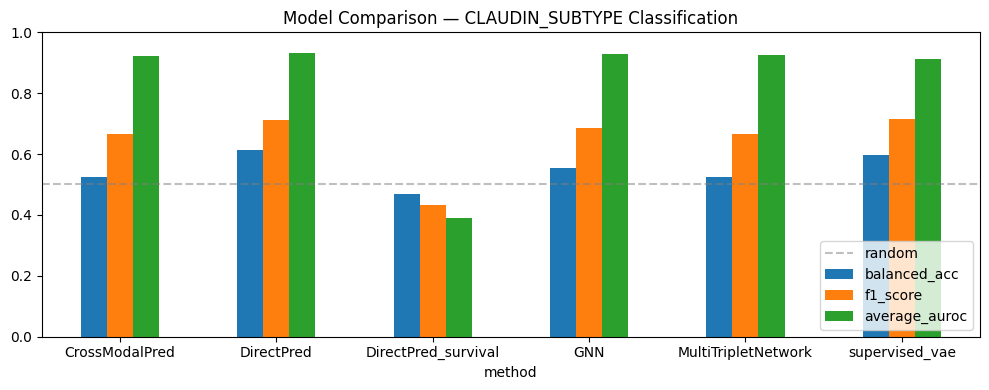

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
pivot[['balanced_acc', 'f1_score', 'average_auroc']].plot(kind='bar', ax=ax, rot=0)
ax.set_title('Model Comparison — CLAUDIN_SUBTYPE Classification')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='random')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [35]:
model_dp.compute_feature_importance(train_dataset, 'CLAUDIN_SUBTYPE')

flexynesis.utils.get_important_features(
    model_dp,
    var='CLAUDIN_SUBTYPE',
    top=15,
)

/home/cykim/flexynesis/flexynesis/utils.py:953: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,target_variable,target_class,target_class_label,layer,name,importance
0,CLAUDIN_SUBTYPE,0,Basal,gex,MSN,0.113611
1,CLAUDIN_SUBTYPE,0,Basal,gex,ARMT1,0.105748
2,CLAUDIN_SUBTYPE,0,Basal,gex,STARD10,0.098365
3,CLAUDIN_SUBTYPE,0,Basal,gex,PRNP,0.096869
4,CLAUDIN_SUBTYPE,0,Basal,gex,AFF3,0.090131
...,...,...,...,...,...,...
100,CLAUDIN_SUBTYPE,6,claudin-low,gex,CDCA3,0.088326
101,CLAUDIN_SUBTYPE,6,claudin-low,gex,KCTD12,0.086381
102,CLAUDIN_SUBTYPE,6,claudin-low,gex,IGFBP4,0.085565
103,CLAUDIN_SUBTYPE,6,claudin-low,gex,CAV1,0.084195
